
# Landslide Segmentation — Full Results, Reproduction & EfficientNet Visualization

This notebook is an internal research-analysis notebook for:

1. **Landslide4Sense public benchmark sanity check**
   - official reported baseline,
   - our `reported-validation` plain U-Net reproduction,
   - our `literal-source` plain U-Net reproduction,
   - our **ImageNet-pretrained EfficientNetV2-S U-Net** experiment,
   - training/checkpoint history,
   - pooled confusion/error statistics,
   - per-image distributions,
   - qualitative validation masks,
   - prediction agreement and change analysis.

2. **EfficientNet model-improvement question**
   - Did EfficientNetV2-S improve the Landslide4Sense result?
   - How did Precision, Recall, F1 and IoU change?
   - How many FP pixels were removed?
   - Did the model become more conservative?
   - Which validation images improved or worsened?

3. **Tillamook strict-binary development experiment**
   - 2×2 depth × feature comparison,
   - Dice / IoU / precision / recall / specificity,
   - FP/FN burden,
   - predicted-positive vs GT-positive prevalence,
   - training curves,
   - threshold sweeps,
   - detailed `deep_7ch` operating-point analysis.

4. **Debugging context**
   - Landslide4Sense and Tillamook are displayed together only for engineering context.
   - They are **not directly comparable benchmarks** because their inputs, resolution,
     labels, losses, architectures, class prevalence and evaluation protocols differ.

**Important:** this notebook does not load or evaluate the locked Tillamook internal test split.


In [1]:

from pathlib import Path
import json
import math
import warnings

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

ROOT = Path.cwd()
# If the notebook is opened somewhere else, uncomment:
# ROOT = Path(r"F:\LIDAR\oregon")

# ---------- Landslide4Sense ----------
L4S_ROOT = Path(r"F:\LIDAR\public_benchmarks\Landslide4sense")

L4S_REPORTED_RUN = ROOT / "public_benchmark_l4s" / "ours_reproduction"
L4S_LITERAL_RUN = ROOT / "public_benchmark_l4s" / "ours_literal_official"
L4S_EFFICIENTNET_RUN = ROOT / "public_benchmark_l4s" / "efficientnetv2_s_pretrained"

L4S_REPORTED_METRICS = L4S_REPORTED_RUN / "metrics.json"
L4S_LITERAL_METRICS = L4S_LITERAL_RUN / "metrics.json"
L4S_EFFICIENTNET_METRICS = L4S_EFFICIENTNET_RUN / "metrics.json"

L4S_REPORTED_HISTORY = L4S_REPORTED_RUN / "history.csv"
L4S_LITERAL_HISTORY = L4S_LITERAL_RUN / "history.csv"
L4S_EFFICIENTNET_HISTORY = L4S_EFFICIENTNET_RUN / "history.csv"

L4S_GT_DIR = L4S_ROOT / "annotations" / "validation"
L4S_IMAGE_DIR = L4S_ROOT / "images" / "validation"

L4S_REPORTED_PRED = L4S_REPORTED_RUN / "validation_predictions"
L4S_LITERAL_PRED = L4S_LITERAL_RUN / "validation_predictions"
L4S_EFFICIENTNET_PRED = L4S_EFFICIENTNET_RUN / "validation_predictions"

# ---------- Tillamook ----------
TILLAMOOK_PHASE3 = ROOT / "dataset_tillamook_100_binary_15m_split641620"
TILLAMOOK_PHASE4 = ROOT / "phase4_tillamook_binary_2x2"

TILLAMOOK_RUNS = {
    "shallow_7ch": TILLAMOOK_PHASE4 / "shallow_7ch",
    "shallow_3ch": TILLAMOOK_PHASE4 / "shallow_3ch",
    "deep_7ch": TILLAMOOK_PHASE4 / "deep_7ch",
    "deep_3ch": TILLAMOOK_PHASE4 / "deep_3ch",
}

FIGDIR = ROOT / "analysis_figures_full"
FIGDIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("Figure output:", FIGDIR)
print()
print("L4S literal metrics exists:", L4S_LITERAL_METRICS.exists())
print("L4S EfficientNet metrics exists:", L4S_EFFICIENTNET_METRICS.exists())
print("L4S reported-validation metrics exists:", L4S_REPORTED_METRICS.exists())
print("Tillamook comparison exists:", (TILLAMOOK_PHASE4 / "comparison.csv").exists())


ROOT: f:\LIDAR\oregon
Figure output: f:\LIDAR\oregon\analysis_figures_full

L4S literal metrics exists: True
L4S EfficientNet metrics exists: True
L4S reported-validation metrics exists: True
Tillamook comparison exists: True


## A. Landslide4Sense — headline reproduction results

In [2]:

OFFICIAL = {
    "precision": 0.5175,
    "recall": 0.6550,
    "f1": 0.5782,
}

def load_json(path):
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else None

reported_obj = load_json(L4S_REPORTED_METRICS)
literal_obj = load_json(L4S_LITERAL_METRICS)
efficientnet_obj = load_json(L4S_EFFICIENTNET_METRICS)

metric_keys = [
    "precision", "recall", "f1", "iou", "overall_accuracy",
    "tp", "fp", "fn", "tn"
]

rows = [{
    "run": "Official reported",
    "precision": OFFICIAL["precision"],
    "recall": OFFICIAL["recall"],
    "f1": OFFICIAL["f1"],
    "iou": np.nan,
    "overall_accuracy": np.nan,
    "tp": np.nan,
    "fp": np.nan,
    "fn": np.nan,
    "tn": np.nan,
}]

if reported_obj is not None:
    m = reported_obj["validation"]
    rows.append({
        "run": "Plain U-Net — reported-validation",
        **{k: m.get(k, np.nan) for k in metric_keys}
    })

if literal_obj is not None:
    m = literal_obj["validation"]
    rows.append({
        "run": "Plain U-Net — literal-source",
        **{k: m.get(k, np.nan) for k in metric_keys}
    })

if efficientnet_obj is not None:
    m = efficientnet_obj["validation"]
    rows.append({
        "run": "EfficientNetV2-S U-Net",
        **{k: m.get(k, np.nan) for k in metric_keys}
    })

l4s_summary = pd.DataFrame(rows)
display(l4s_summary.round(4))

if literal_obj is not None:
    lit = literal_obj["validation"]
    print("Plain literal-source absolute differences from official:")
    print(f"  Precision: {abs(lit['precision'] - OFFICIAL['precision']):.4f}")
    print(f"  Recall:    {abs(lit['recall'] - OFFICIAL['recall']):.4f}")
    print(f"  F1:        {abs(lit['f1'] - OFFICIAL['f1']):.4f}")

if efficientnet_obj is not None and literal_obj is not None:
    e = efficientnet_obj["validation"]
    p = literal_obj["validation"]
    print()
    print("EfficientNetV2-S change vs plain literal-source U-Net:")
    print(f"  Precision: {e['precision'] - p['precision']:+.4f}")
    print(f"  Recall:    {e['recall'] - p['recall']:+.4f}")
    print(f"  F1:        {e['f1'] - p['f1']:+.4f}")
    print(f"  IoU:       {e['iou'] - p['iou']:+.4f}")
    print(f"  FP pixels: {e['fp'] - p['fp']:+,}")
    print(f"  FN pixels: {e['fn'] - p['fn']:+,}")


,run,precision,recall,f1,iou,overall_accuracy,tp,fp,fn,tn
0,Official reported,0.5175,0.6550,0.5782,NaN,NaN,NaN,NaN,NaN,NaN
1,Plain U-Net — reported-validation,0.6677,0.5980,0.6309,0.4609,0.9880,41110.0,20458.0,27635.0,3924877.0
2,Plain U-Net — literal-source,0.5449,0.6577,0.5960,0.4245,0.9847,45217.0,37763.0,23528.0,3907572.0
3,EfficientNetV2-S U-Net,0.6301,0.6026,0.6161,0.4452,0.9871,41427.0,24317.0,27318.0,3921018.0


Plain literal-source absolute differences from official:
  Precision: 0.0274
  Recall:    0.0027
  F1:        0.0178

EfficientNetV2-S change vs plain literal-source U-Net:
  Precision: +0.0852
  Recall:    -0.0551
  F1:        +0.0200
  IoU:       +0.0206
  FP pixels: -13,446
  FN pixels: +3,790


### A1. Official vs our reproduction — Precision / Recall / F1

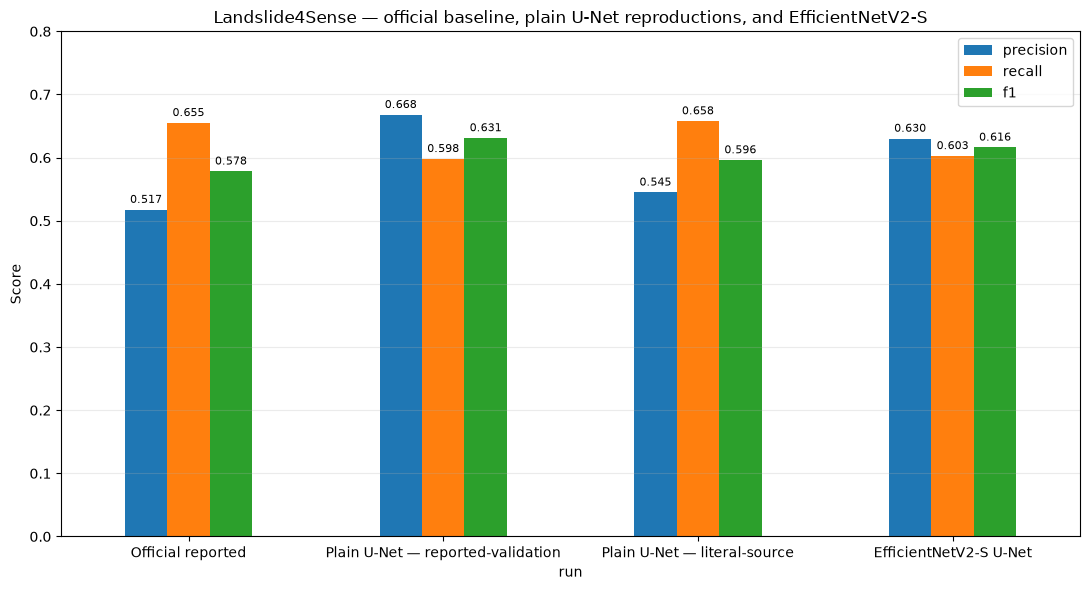

In [3]:

plot_df = l4s_summary.set_index("run")[["precision","recall","f1"]]

ax = plot_df.plot(kind="bar", figsize=(11, 6), rot=0)
ax.set_title("Landslide4Sense — official baseline, plain U-Net reproductions, and EfficientNetV2-S")
ax.set_ylabel("Score")
ax.set_ylim(0, 0.8)
ax.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

plt.tight_layout()
plt.savefig(FIGDIR / "l4s_headline_metrics.png", dpi=180, bbox_inches="tight")
plt.show()


### A2. Absolute difference from the published baseline

,run,precision_delta,recall_delta,f1_delta
0,Plain U-Net — reported-validation,0.1502,0.0570,0.0527
1,Plain U-Net — literal-source,0.0274,0.0027,0.0178
2,EfficientNetV2-S U-Net,0.1126,0.0524,0.0379


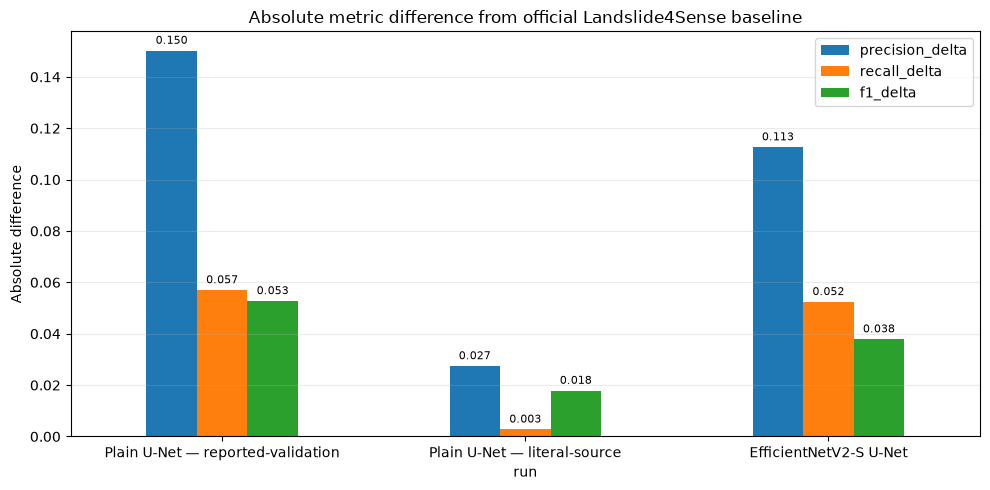

In [4]:

delta_rows = []

for _, r in l4s_summary.iterrows():
    if r["run"] == "Official reported":
        continue
    delta_rows.append({
        "run": r["run"],
        "precision_delta": abs(r["precision"] - OFFICIAL["precision"]),
        "recall_delta": abs(r["recall"] - OFFICIAL["recall"]),
        "f1_delta": abs(r["f1"] - OFFICIAL["f1"]),
    })

delta_df = pd.DataFrame(delta_rows)
display(delta_df.round(4))

if not delta_df.empty:
    ax = delta_df.set_index("run").plot(kind="bar", figsize=(10,5), rot=0)
    ax.set_title("Absolute metric difference from official Landslide4Sense baseline")
    ax.set_ylabel("Absolute difference")
    ax.grid(axis="y", alpha=0.25)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGDIR / "l4s_absolute_metric_delta.png", dpi=180, bbox_inches="tight")
    plt.show()


### A3. Literal-source pooled confusion matrix

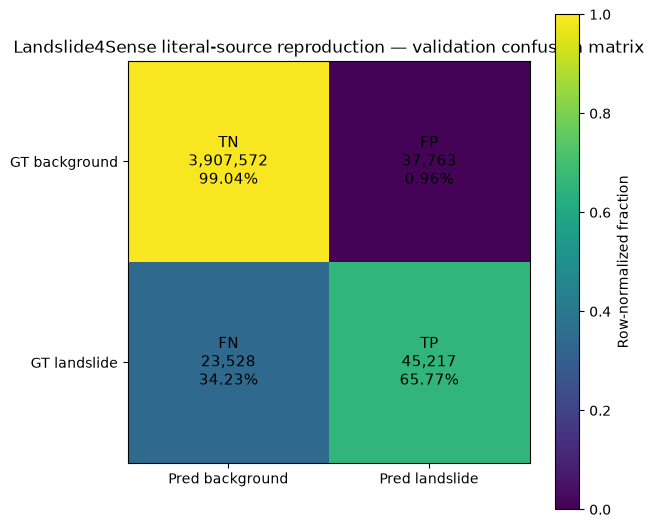

In [5]:

def plot_confusion(tp, fp, fn, tn, title, filename):
    cm = np.array([[tn, fp], [fn, tp]], dtype=np.float64)
    cm_row = cm / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(cm_row, vmin=0, vmax=1)
    ax.set_xticks([0,1], ["Pred background", "Pred landslide"])
    ax.set_yticks([0,1], ["GT background", "GT landslide"])
    ax.set_title(title)

    labels = [
        [f"TN\n{int(tn):,}\n{cm_row[0,0]:.2%}", f"FP\n{int(fp):,}\n{cm_row[0,1]:.2%}"],
        [f"FN\n{int(fn):,}\n{cm_row[1,0]:.2%}", f"TP\n{int(tp):,}\n{cm_row[1,1]:.2%}"],
    ]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, labels[i][j], ha="center", va="center", fontsize=11)

    fig.colorbar(im, ax=ax, label="Row-normalized fraction")
    plt.tight_layout()
    plt.savefig(FIGDIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

if literal_obj is not None:
    m = literal_obj["validation"]
    plot_confusion(
        m["tp"], m["fp"], m["fn"], m["tn"],
        "Landslide4Sense literal-source reproduction — validation confusion matrix",
        "l4s_literal_confusion_matrix.png"
    )


### A4. Precision–recall operating points

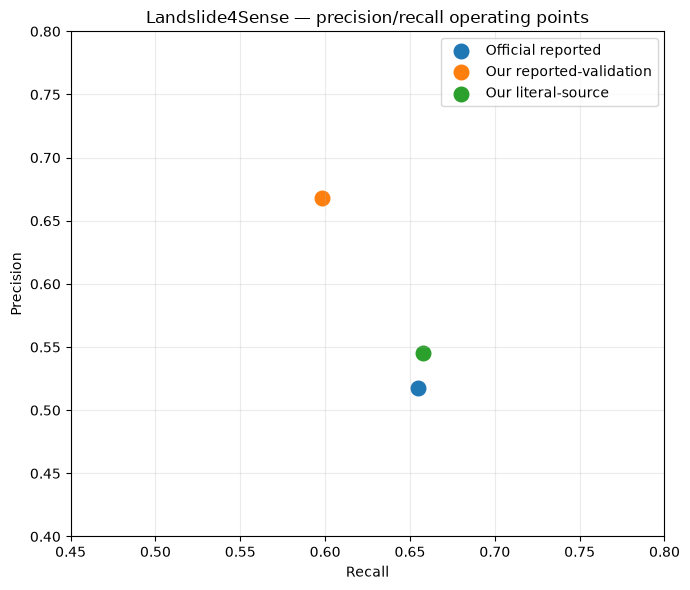

In [6]:

fig, ax = plt.subplots(figsize=(7,6))

ax.scatter([OFFICIAL["recall"]], [OFFICIAL["precision"]], s=110, label="Official reported")

if reported_obj is not None:
    m = reported_obj["validation"]
    ax.scatter([m["recall"]], [m["precision"]], s=110, label="Our reported-validation")

if literal_obj is not None:
    m = literal_obj["validation"]
    ax.scatter([m["recall"]], [m["precision"]], s=110, label="Our literal-source")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Landslide4Sense — precision/recall operating points")
ax.set_xlim(0.45, 0.8)
ax.set_ylim(0.4, 0.8)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.savefig(FIGDIR / "l4s_precision_recall_points.png", dpi=180, bbox_inches="tight")
plt.show()



### A5. EfficientNetV2-S improvement over the plain literal-source U-Net

This is the main professor-requested model check. The reference for this comparison is
our independently reproduced **plain U-Net under the literal-source protocol**:

- Plain U-Net F1: approximately **0.5960**
- EfficientNetV2-S U-Net F1: approximately **0.6161**

The experiment changes the encoder architecture **and** introduces ImageNet pretraining,
so this measures the practical benefit of the EfficientNet-based model rather than an
isolated causal effect of architecture alone.


,model,precision,recall,f1,iou,fp,fn
0,Plain U-Net,0.5449,0.6577,0.5960,0.4245,37763,23528
1,EfficientNetV2-S U-Net,0.6301,0.6026,0.6161,0.4452,24317,27318


,value
precision_change,0.0852
recall_change,-0.0551
f1_change,0.0200
iou_change,0.0206
fp_change,-13446.0000
fn_change,3790.0000
fp_reduction_percent,35.6063
fn_increase_percent,16.1085
relative_f1_change_percent,3.3599


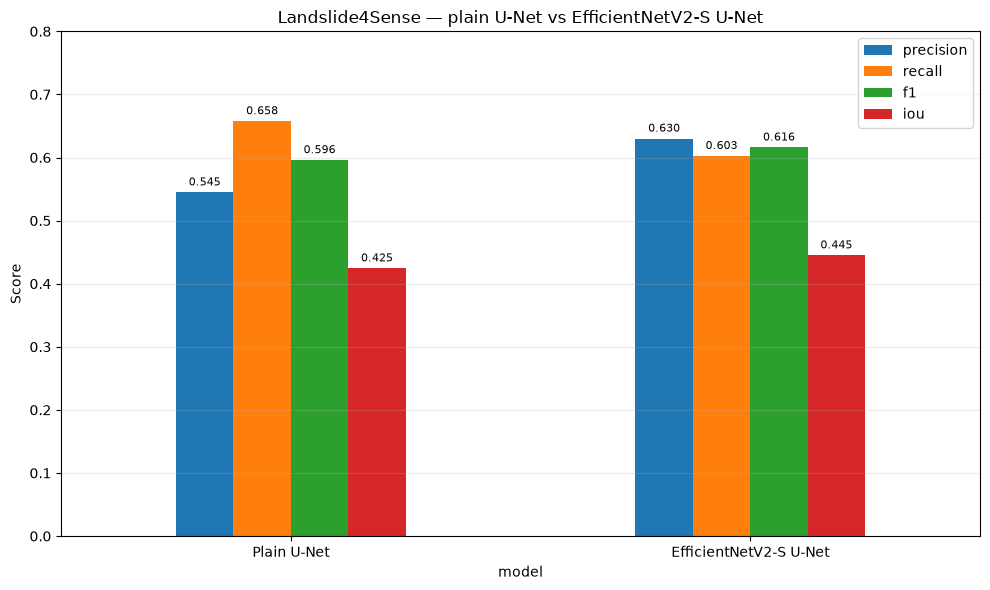

In [7]:

if efficientnet_obj is not None and literal_obj is not None:
    p = literal_obj["validation"]
    e = efficientnet_obj["validation"]

    comparison_eff = pd.DataFrame([
        {
            "model": "Plain U-Net",
            "precision": p["precision"],
            "recall": p["recall"],
            "f1": p["f1"],
            "iou": p["iou"],
            "fp": p["fp"],
            "fn": p["fn"],
        },
        {
            "model": "EfficientNetV2-S U-Net",
            "precision": e["precision"],
            "recall": e["recall"],
            "f1": e["f1"],
            "iou": e["iou"],
            "fp": e["fp"],
            "fn": e["fn"],
        },
    ])

    display(comparison_eff.round(4))

    delta_eff = {
        "precision_change": e["precision"] - p["precision"],
        "recall_change": e["recall"] - p["recall"],
        "f1_change": e["f1"] - p["f1"],
        "iou_change": e["iou"] - p["iou"],
        "fp_change": e["fp"] - p["fp"],
        "fn_change": e["fn"] - p["fn"],
        "fp_reduction_percent": 100 * (p["fp"] - e["fp"]) / p["fp"],
        "fn_increase_percent": 100 * (e["fn"] - p["fn"]) / p["fn"],
        "relative_f1_change_percent": 100 * (e["f1"] - p["f1"]) / p["f1"],
    }

    display(pd.Series(delta_eff).to_frame("value").round(4))

    metric_compare = comparison_eff.set_index("model")[["precision","recall","f1","iou"]]
    ax = metric_compare.plot(kind="bar", figsize=(10,6), rot=0)
    ax.set_title("Landslide4Sense — plain U-Net vs EfficientNetV2-S U-Net")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 0.8)
    ax.grid(axis="y", alpha=0.25)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGDIR / "l4s_plain_vs_efficientnet_metrics.png", dpi=180, bbox_inches="tight")
    plt.show()


### A6. False-positive / false-negative change

,FP,FN
model,,
Plain U-Net,37763,23528
EfficientNetV2-S U-Net,24317,27318


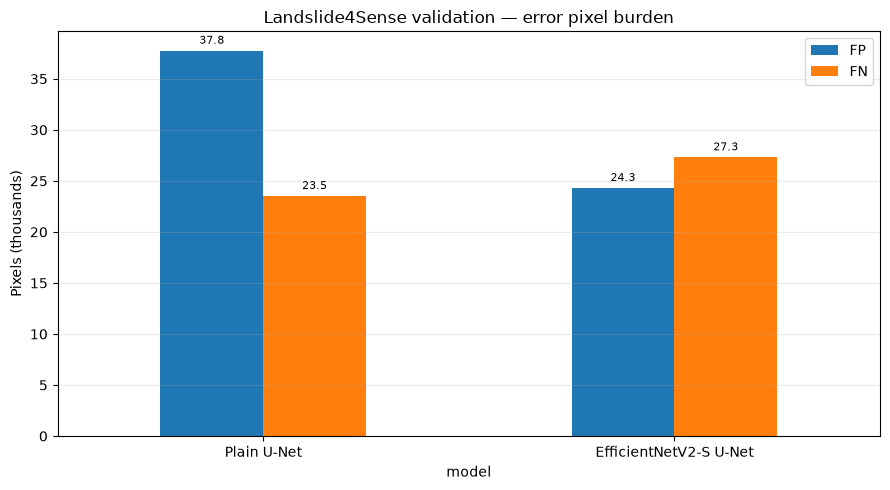

FP reduction: 35.61%
FN increase:  16.11%


In [8]:

if efficientnet_obj is not None and literal_obj is not None:
    p = literal_obj["validation"]
    e = efficientnet_obj["validation"]

    error_df = pd.DataFrame([
        {"model": "Plain U-Net", "FP": p["fp"], "FN": p["fn"]},
        {"model": "EfficientNetV2-S U-Net", "FP": e["fp"], "FN": e["fn"]},
    ]).set_index("model")

    display(error_df)

    ax = (error_df / 1000.0).plot(kind="bar", figsize=(9,5), rot=0)
    ax.set_title("Landslide4Sense validation — error pixel burden")
    ax.set_ylabel("Pixels (thousands)")
    ax.grid(axis="y", alpha=0.25)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3, fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGDIR / "l4s_plain_vs_efficientnet_fp_fn.png", dpi=180, bbox_inches="tight")
    plt.show()

    print(f"FP reduction: {100*(p['fp']-e['fp'])/p['fp']:.2f}%")
    print(f"FN increase:  {100*(e['fn']-p['fn'])/p['fn']:.2f}%")


### A7. Positive-area prevalence

,label,positive_fraction,positive_percent
0,Ground truth,0.0171,1.7126
1,Plain U-Net,0.0207,2.0672
2,EfficientNetV2-S U-Net,0.0164,1.6378


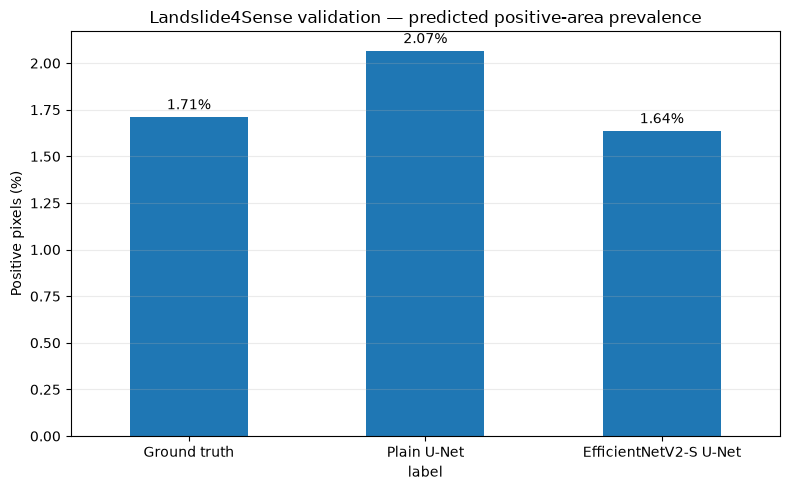

In [9]:

if efficientnet_obj is not None and literal_obj is not None:
    p = literal_obj["validation"]
    e = efficientnet_obj["validation"]

    total = p["tp"] + p["fp"] + p["fn"] + p["tn"]
    gt_positive = (p["tp"] + p["fn"]) / total

    prev_df = pd.DataFrame([
        {"label": "Ground truth", "positive_fraction": gt_positive},
        {"label": "Plain U-Net", "positive_fraction": (p["tp"] + p["fp"]) / total},
        {"label": "EfficientNetV2-S U-Net", "positive_fraction": (e["tp"] + e["fp"]) / total},
    ])

    prev_df["positive_percent"] = 100 * prev_df["positive_fraction"]
    display(prev_df.round(4))

    ax = prev_df.set_index("label")[["positive_percent"]].plot(
        kind="bar", figsize=(8,5), rot=0, legend=False
    )
    ax.set_title("Landslide4Sense validation — predicted positive-area prevalence")
    ax.set_ylabel("Positive pixels (%)")
    ax.grid(axis="y", alpha=0.25)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f%%", padding=3)
    plt.tight_layout()
    plt.savefig(FIGDIR / "l4s_plain_vs_efficientnet_positive_area.png", dpi=180, bbox_inches="tight")
    plt.show()


## B. Landslide4Sense — training history

In [10]:

def read_history(path):
    if not path.exists():
        print("Missing:", path)
        return None
    return pd.read_csv(path)

hist_reported = read_history(L4S_REPORTED_HISTORY)
hist_literal = read_history(L4S_LITERAL_HISTORY)
hist_efficientnet = read_history(L4S_EFFICIENTNET_HISTORY)

for name, h in [
    ("reported-validation plain U-Net", hist_reported),
    ("literal-source plain U-Net", hist_literal),
    ("EfficientNetV2-S U-Net", hist_efficientnet),
]:
    if h is not None:
        print(name, h.shape)
        print("columns:", h.columns.tolist())


reported-validation plain U-Net (5000, 13)
columns: ['eval_f1', 'eval_fn', 'eval_fp', 'eval_iou', 'eval_overall_accuracy', 'eval_precision', 'eval_recall', 'eval_tn', 'eval_tp', 'step', 'step_seconds', 'train_batch_oa', 'train_loss']
literal-source plain U-Net (5000, 13)
columns: ['eval_f1', 'eval_fn', 'eval_fp', 'eval_iou', 'eval_overall_accuracy', 'eval_precision', 'eval_recall', 'eval_tn', 'eval_tp', 'step', 'step_seconds', 'train_batch_oa', 'train_loss']
EfficientNetV2-S U-Net (5000, 12)
columns: ['elapsed_seconds', 'optimizer_step', 'select_f1', 'select_fn', 'select_fp', 'select_iou', 'select_overall_accuracy', 'select_precision', 'select_recall', 'select_tn', 'select_tp', 'train_loss_recent']


### B1. Training loss over optimizer steps

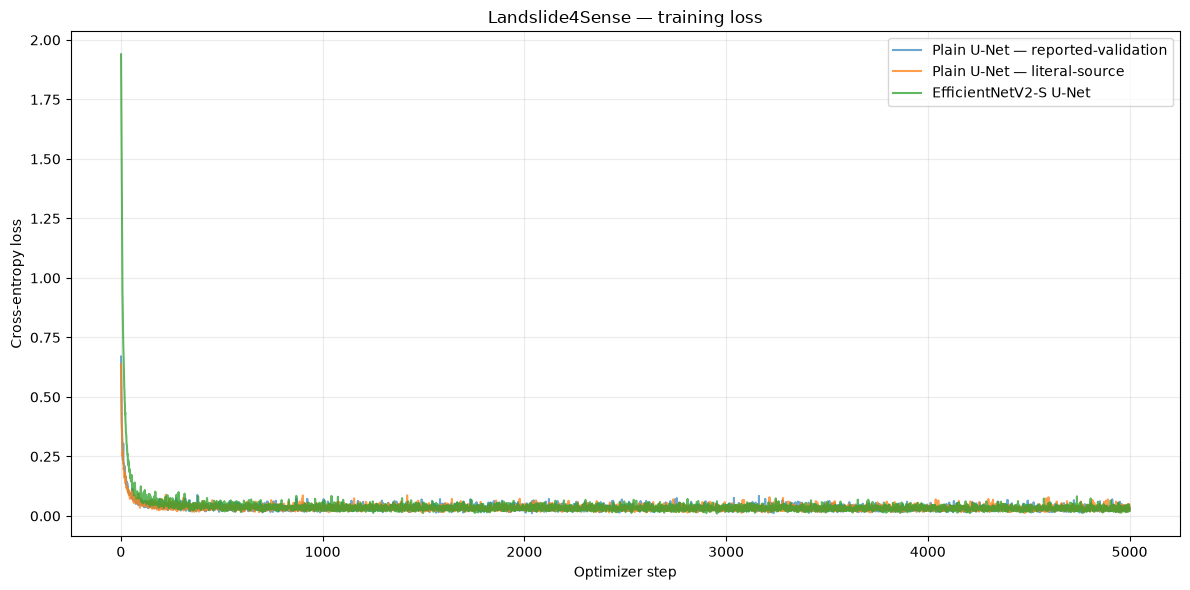

In [11]:

fig, ax = plt.subplots(figsize=(12,6))

if hist_reported is not None and "train_loss" in hist_reported:
    ax.plot(
        hist_reported["step"],
        hist_reported["train_loss"],
        alpha=0.65,
        label="Plain U-Net — reported-validation"
    )

if hist_literal is not None and "train_loss" in hist_literal:
    ax.plot(
        hist_literal["step"],
        hist_literal["train_loss"],
        alpha=0.75,
        label="Plain U-Net — literal-source"
    )

if hist_efficientnet is not None:
    xcol = "optimizer_step" if "optimizer_step" in hist_efficientnet else "step"
    ycol = "train_loss_recent" if "train_loss_recent" in hist_efficientnet else "train_loss"
    if xcol in hist_efficientnet and ycol in hist_efficientnet:
        ax.plot(
            hist_efficientnet[xcol],
            hist_efficientnet[ycol],
            alpha=0.75,
            label="EfficientNetV2-S U-Net"
        )

ax.set_xlabel("Optimizer step")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Landslide4Sense — training loss")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "l4s_training_loss_with_efficientnet.png", dpi=180, bbox_inches="tight")
plt.show()


### B2. Evaluation F1 at checkpoint-selection steps

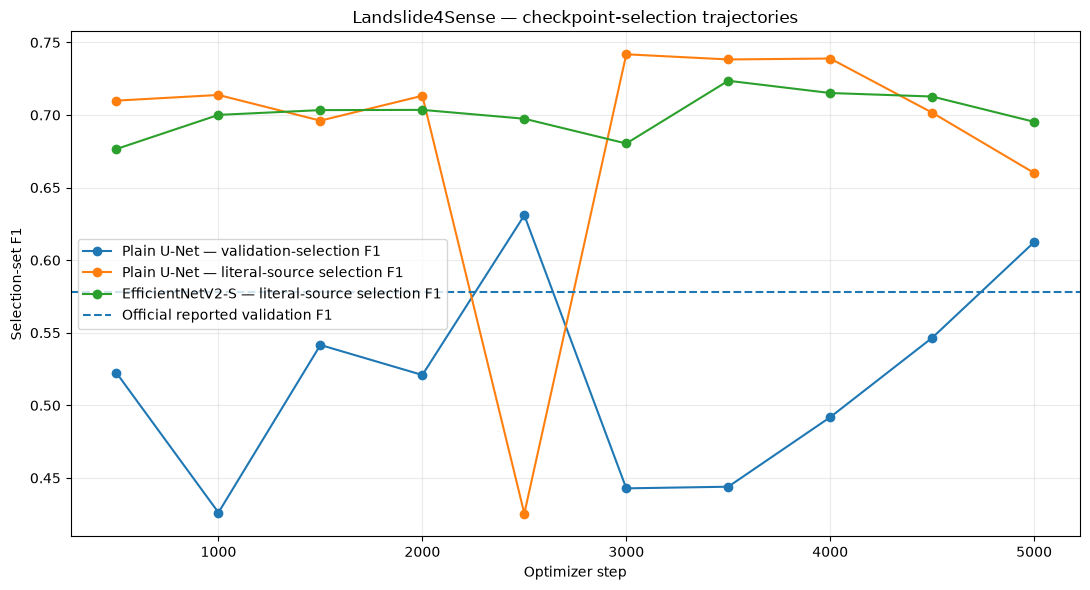

,optimizer_step,train_loss_recent,select_precision,select_recall,select_f1,select_iou
499,500,0.0200,0.7883,0.5926,0.6766,0.5113
999,1000,0.0350,0.7007,0.6994,0.7001,0.5386
1499,1500,0.0572,0.8170,0.6175,0.7034,0.5425
1999,2000,0.0344,0.8189,0.6166,0.7035,0.5427
2499,2500,0.0431,0.7931,0.6224,0.6974,0.5354
2999,3000,0.0201,0.8547,0.5651,0.6804,0.5156
3499,3500,0.0220,0.8199,0.6475,0.7236,0.5669
3999,4000,0.0294,0.8079,0.6415,0.7152,0.5566
4499,4500,0.0237,0.7945,0.6463,0.7127,0.5537
4999,5000,0.0206,0.8334,0.5965,0.6953,0.5329


In [12]:

def sparse_plain_eval(h):
    if h is None or "eval_f1" not in h.columns:
        return None
    return h[h["eval_f1"].notna()].copy()

def sparse_eff_eval(h):
    if h is None:
        return None
    if "select_f1" not in h.columns:
        return None
    return h[h["select_f1"].notna()].copy()

er = sparse_plain_eval(hist_reported)
el = sparse_plain_eval(hist_literal)
ee = sparse_eff_eval(hist_efficientnet)

fig, ax = plt.subplots(figsize=(11,6))

if er is not None and not er.empty:
    ax.plot(er["step"], er["eval_f1"], marker="o", label="Plain U-Net — validation-selection F1")

if el is not None and not el.empty:
    ax.plot(el["step"], el["eval_f1"], marker="o", label="Plain U-Net — literal-source selection F1")

if ee is not None and not ee.empty:
    ax.plot(
        ee["optimizer_step"],
        ee["select_f1"],
        marker="o",
        label="EfficientNetV2-S — literal-source selection F1"
    )

ax.axhline(OFFICIAL["f1"], linestyle="--", label="Official reported validation F1")
ax.set_xlabel("Optimizer step")
ax.set_ylabel("Selection-set F1")
ax.set_title("Landslide4Sense — checkpoint-selection trajectories")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "l4s_checkpoint_selection_f1_with_efficientnet.png", dpi=180, bbox_inches="tight")
plt.show()

if ee is not None:
    cols = [c for c in [
        "optimizer_step", "train_loss_recent",
        "select_precision", "select_recall", "select_f1", "select_iou"
    ] if c in ee.columns]
    display(ee[cols].round(4))



**Interpretation caution:** in the `literal-source` reproduction, the periodic evaluation used for checkpoint selection mirrors the official source-code behavior and therefore evaluates the training list. The final reported value in `metrics.json` is the selected checkpoint evaluated on the actual validation labels.


## C. Landslide4Sense — per-image validation analysis

In [13]:

def read_mask(path):
    with h5py.File(path, "r") as hf:
        if "mask" in hf:
            arr = hf["mask"][:]
        else:
            keys = list(hf.keys())
            arr = hf[keys[0]][:]
    arr = np.asarray(arr)
    return np.squeeze(arr)

def numeric_id(path):
    digits = "".join(c for c in path.stem if c.isdigit())
    return int(digits) if digits else 10**12

def per_image_metrics(gt_dir, pred_dir):
    rows = []
    for gt_path in sorted(gt_dir.glob("mask_*.h5"), key=numeric_id):
        pred_path = pred_dir / gt_path.name
        if not pred_path.exists():
            continue

        gt = read_mask(gt_path)
        pred = read_mask(pred_path)

        valid = (gt >= 0) & (gt < 2)
        truth = gt == 1
        pos = pred == 1

        tp = int((pos & truth & valid).sum())
        fp = int((pos & ~truth & valid).sum())
        fn = int((~pos & truth & valid).sum())
        tn = int((~pos & ~truth & valid).sum())

        def ratio(a,b):
            return a/b if b else np.nan

        p = ratio(tp, tp+fp)
        r = ratio(tp, tp+fn)
        f1 = ratio(2*tp, 2*tp+fp+fn)
        iou = ratio(tp, tp+fp+fn)

        rows.append({
            "mask": gt_path.name,
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": p, "recall": r, "f1": f1, "iou": iou,
            "gt_positive_fraction": truth[valid].mean(),
            "pred_positive_fraction": pos[valid].mean(),
        })
    return pd.DataFrame(rows)

literal_per_image = None
reported_per_image = None
efficientnet_per_image = None

if L4S_LITERAL_PRED.exists() and L4S_GT_DIR.exists():
    literal_per_image = per_image_metrics(L4S_GT_DIR, L4S_LITERAL_PRED)
    print("Literal per-image rows:", len(literal_per_image))

if L4S_REPORTED_PRED.exists() and L4S_GT_DIR.exists():
    reported_per_image = per_image_metrics(L4S_GT_DIR, L4S_REPORTED_PRED)
    print("Reported-validation per-image rows:", len(reported_per_image))


if L4S_EFFICIENTNET_PRED.exists() and L4S_GT_DIR.exists():
    efficientnet_per_image = per_image_metrics(L4S_GT_DIR, L4S_EFFICIENTNET_PRED)
    print("EfficientNet per-image rows:", len(efficientnet_per_image))


Literal per-image rows: 245
Reported-validation per-image rows: 245
EfficientNet per-image rows: 245


### C1. Distribution of per-image F1

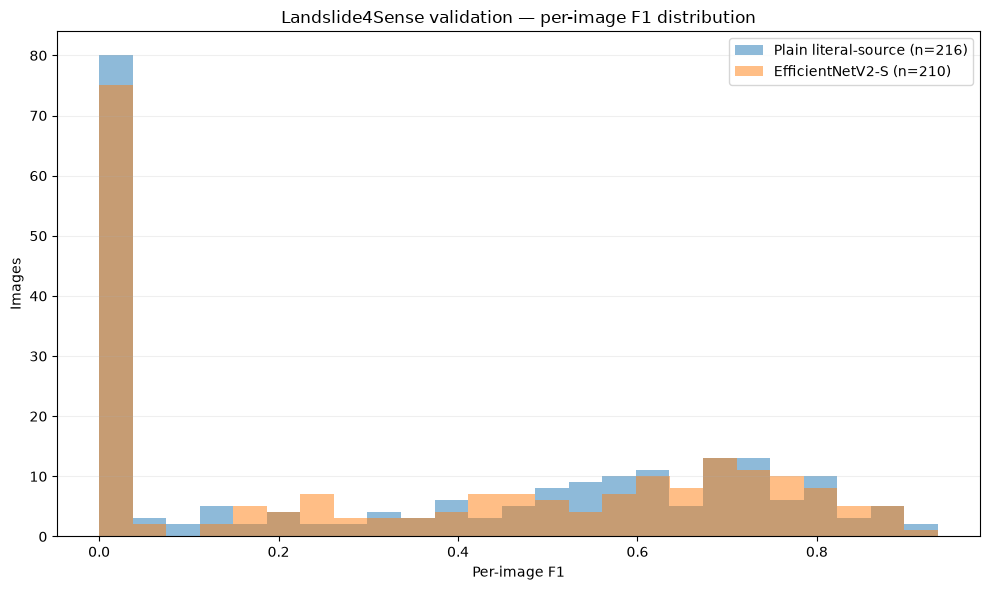

Plain U-Net per-image summary


,precision,recall,f1,iou,gt_positive_fraction,pred_positive_fraction
count,210.0000,146.0000,216.0000,216.0000,245.0000,245.0000
mean,0.3654,0.6400,0.3532,0.2644,0.0171,0.0207
std,0.3340,0.2793,0.3215,0.2598,0.0608,0.0477
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.4824,0.0000,0.0000,0.0000,0.0010
50%,0.3772,0.7186,0.3847,0.2382,0.0021,0.0068
75%,0.6743,0.8571,0.6540,0.4859,0.0148,0.0270
max,1.0000,1.0000,0.9347,0.8775,0.6165,0.5041


EfficientNetV2-S per-image summary


,precision,recall,f1,iou,gt_positive_fraction,pred_positive_fraction
count,207.0000,146.0000,210.0000,210.0000,245.0000,245.0000
mean,0.3970,0.5716,0.3604,0.2699,0.0171,0.0164
std,0.3545,0.2711,0.3204,0.2601,0.0608,0.0426
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.4273,0.0000,0.0000,0.0000,0.0010
50%,0.4000,0.6200,0.3771,0.2324,0.0021,0.0058
75%,0.7432,0.7802,0.6732,0.5074,0.0148,0.0178
max,1.0000,1.0000,0.9350,0.8780,0.6165,0.4503


In [14]:

fig, ax = plt.subplots(figsize=(10,6))

if literal_per_image is not None:
    vals = literal_per_image["f1"].dropna()
    ax.hist(vals, bins=25, alpha=0.50, label=f"Plain literal-source (n={len(vals)})")

if efficientnet_per_image is not None:
    vals = efficientnet_per_image["f1"].dropna()
    ax.hist(vals, bins=25, alpha=0.50, label=f"EfficientNetV2-S (n={len(vals)})")

ax.set_xlabel("Per-image F1")
ax.set_ylabel("Images")
ax.set_title("Landslide4Sense validation — per-image F1 distribution")
ax.legend()
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(FIGDIR / "l4s_per_image_f1_plain_vs_efficientnet.png", dpi=180, bbox_inches="tight")
plt.show()

if literal_per_image is not None:
    print("Plain U-Net per-image summary")
    display(
        literal_per_image[
            ["precision","recall","f1","iou","gt_positive_fraction","pred_positive_fraction"]
        ].describe().round(4)
    )

if efficientnet_per_image is not None:
    print("EfficientNetV2-S per-image summary")
    display(
        efficientnet_per_image[
            ["precision","recall","f1","iou","gt_positive_fraction","pred_positive_fraction"]
        ].describe().round(4)
    )


### C2. F1 versus landslide prevalence

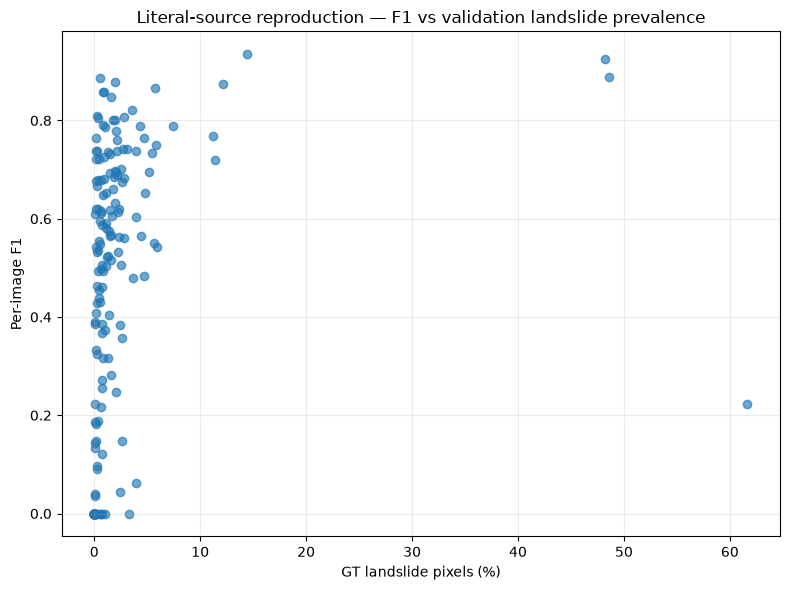

In [15]:

if literal_per_image is not None:
    d = literal_per_image.replace([np.inf,-np.inf], np.nan).dropna(subset=["f1","gt_positive_fraction"])

    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(100*d["gt_positive_fraction"], d["f1"], alpha=0.65)
    ax.set_xlabel("GT landslide pixels (%)")
    ax.set_ylabel("Per-image F1")
    ax.set_title("Literal-source reproduction — F1 vs validation landslide prevalence")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGDIR / "l4s_f1_vs_gt_prevalence.png", dpi=180, bbox_inches="tight")
    plt.show()


### C3. Best / worst validation images

In [16]:

if literal_per_image is not None:
    valid_f1 = literal_per_image.dropna(subset=["f1"]).copy()

    print("Lowest F1:")
    display(valid_f1.nsmallest(10, "f1")[["mask","f1","precision","recall","fp","fn","gt_positive_fraction","pred_positive_fraction"]].round(4))

    print("Highest F1:")
    display(valid_f1.nlargest(10, "f1")[["mask","f1","precision","recall","fp","fn","gt_positive_fraction","pred_positive_fraction"]].round(4))

    valid_f1.to_csv(FIGDIR / "l4s_literal_per_image_metrics.csv", index=False)


Lowest F1:


,mask,f1,precision,recall,fp,fn,gt_positive_fraction,pred_positive_fraction
0,mask_1.h5,0.0,0.0,NaN,209,0,0.0000,0.0128
11,mask_12.h5,0.0,0.0,NaN,1,0,0.0000,0.0001
12,mask_13.h5,0.0,0.0,NaN,1395,0,0.0000,0.0851
16,mask_17.h5,0.0,0.0,0.0,6,8,0.0005,0.0004
21,mask_22.h5,0.0,0.0,NaN,39,0,0.0000,0.0024
22,mask_23.h5,0.0,0.0,NaN,61,0,0.0000,0.0037
24,mask_25.h5,0.0,0.0,NaN,57,0,0.0000,0.0035
26,mask_27.h5,0.0,0.0,NaN,3,0,0.0000,0.0002
29,mask_30.h5,0.0,0.0,NaN,35,0,0.0000,0.0021
30,mask_31.h5,0.0,0.0,NaN,55,0,0.0000,0.0034


Highest F1:


,mask,f1,precision,recall,fp,fn,gt_positive_fraction,pred_positive_fraction
166,mask_167.h5,0.9347,0.9124,0.9582,218,99,0.1446,0.1519
50,mask_51.h5,0.9257,0.9820,0.8756,127,982,0.4818,0.4296
151,mask_152.h5,0.8890,0.8727,0.9059,1051,749,0.4857,0.5041
64,mask_65.h5,0.8865,0.8817,0.8913,11,10,0.0056,0.0057
168,mask_169.h5,0.8784,0.8253,0.9388,65,20,0.0200,0.0227
222,mask_223.h5,0.8739,0.8209,0.9342,406,131,0.1216,0.1384
104,mask_105.h5,0.8658,0.8382,0.8954,162,98,0.0572,0.0611
146,mask_147.h5,0.8588,0.7760,0.9613,43,6,0.0095,0.0117
35,mask_36.h5,0.8571,0.7582,0.9857,44,2,0.0085,0.0111
231,mask_232.h5,0.8480,0.7676,0.9472,76,14,0.0162,0.0200


### C4. Which validation images improved with EfficientNet?

Per-image F1 change summary:


count    203.0000
mean      -0.0030
std        0.1045
min       -0.5358
25%       -0.0264
50%        0.0000
75%        0.0227
max        0.5037
Name: f1_change, dtype: float64

Images with improved F1: 69
Images with worse F1:    70
Images unchanged:        64


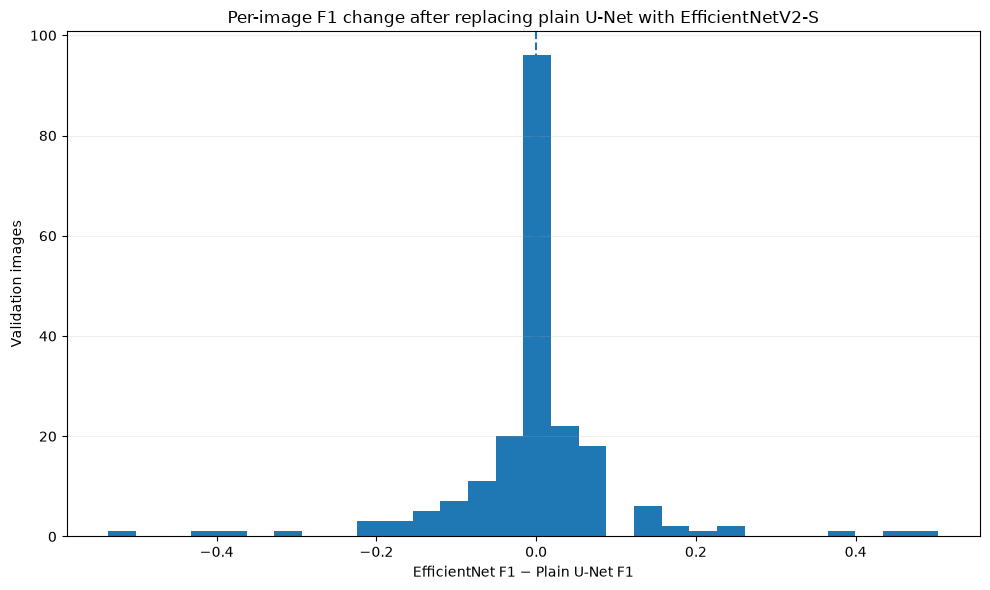

Largest improvements:


,mask,f1_plain,f1_efficientnet,f1_change,precision_change,recall_change,fp_change,fn_change
196,mask_197.h5,0.2476,0.7513,0.5037,0.1538,0.5103,13,-174
71,mask_72.h5,0.0962,0.5333,0.4372,0.3422,0.5143,-121,-18
224,mask_225.h5,0.0000,0.3901,0.3901,NaN,0.2886,104,-157
76,mask_77.h5,0.0436,0.2804,0.2368,-0.2380,0.2242,197,-89
107,mask_108.h5,0.0000,0.2268,0.2268,NaN,0.1760,47,-22
155,mask_156.h5,0.3246,0.5243,0.1997,0.2233,-0.1000,-84,4
129,mask_130.h5,0.0000,0.1875,0.1875,NaN,0.1622,63,-18
109,mask_110.h5,0.5325,0.6903,0.1577,0.2281,-0.1250,-50,6
98,mask_99.h5,0.5036,0.6552,0.1516,0.1494,0.1389,-13,-25
240,mask_241.h5,0.3839,0.5175,0.1336,0.1661,-0.2450,-804,99


Largest regressions:


,mask,f1_plain,f1_efficientnet,f1_change,precision_change,recall_change,fp_change,fn_change
57,mask_58.h5,0.7636,0.2278,-0.5358,-0.8548,-0.0882,106,3
233,mask_234.h5,0.4286,0.0000,-0.4286,-0.4839,-0.3846,1,15
218,mask_219.h5,0.6202,0.2410,-0.3792,-0.1548,-0.5085,-16,30
13,mask_14.h5,0.5417,0.2222,-0.3194,-0.1909,-0.3462,-3,9
91,mask_92.h5,0.2222,0.0000,-0.2222,-0.1429,-0.5000,-23,4
149,mask_150.h5,0.6667,0.4505,-0.2162,-0.3269,-0.0682,30,3
228,mask_229.h5,0.6029,0.4129,-0.1900,-0.1789,-0.0590,744,38
45,mask_46.h5,0.1831,0.0000,-0.1831,-0.1083,-0.5909,-52,13
173,mask_174.h5,0.6087,0.4286,-0.1801,0.4167,-0.3636,-5,4
199,mask_200.h5,0.3889,0.2200,-0.1689,-0.1667,0.3333,60,-4


In [17]:

if literal_per_image is not None and efficientnet_per_image is not None:
    merged = literal_per_image.merge(
        efficientnet_per_image,
        on="mask",
        suffixes=("_plain", "_efficientnet"),
    )

    for metric in ["f1","precision","recall","iou","fp","fn","pred_positive_fraction"]:
        merged[f"{metric}_change"] = (
            merged[f"{metric}_efficientnet"] - merged[f"{metric}_plain"]
        )

    print("Per-image F1 change summary:")
    display(merged["f1_change"].describe().round(4))

    print("Images with improved F1:", int((merged["f1_change"] > 0).sum()))
    print("Images with worse F1:   ", int((merged["f1_change"] < 0).sum()))
    print("Images unchanged:       ", int((merged["f1_change"] == 0).sum()))

    fig, ax = plt.subplots(figsize=(10,6))
    ax.hist(merged["f1_change"].dropna(), bins=30)
    ax.axvline(0, linestyle="--")
    ax.set_xlabel("EfficientNet F1 − Plain U-Net F1")
    ax.set_ylabel("Validation images")
    ax.set_title("Per-image F1 change after replacing plain U-Net with EfficientNetV2-S")
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.savefig(FIGDIR / "l4s_per_image_f1_change_efficientnet.png", dpi=180, bbox_inches="tight")
    plt.show()

    print("Largest improvements:")
    display(
        merged.nlargest(10, "f1_change")[
            [
                "mask",
                "f1_plain","f1_efficientnet","f1_change",
                "precision_change","recall_change",
                "fp_change","fn_change"
            ]
        ].round(4)
    )

    print("Largest regressions:")
    display(
        merged.nsmallest(10, "f1_change")[
            [
                "mask",
                "f1_plain","f1_efficientnet","f1_change",
                "precision_change","recall_change",
                "fp_change","fn_change"
            ]
        ].round(4)
    )

    merged.to_csv(FIGDIR / "l4s_plain_vs_efficientnet_per_image_change.csv", index=False)


## D. Landslide4Sense — qualitative prediction maps

Selected examples: ['mask_1.h5', 'mask_12.h5', 'mask_19.h5', 'mask_132.h5', 'mask_167.h5', 'mask_51.h5']


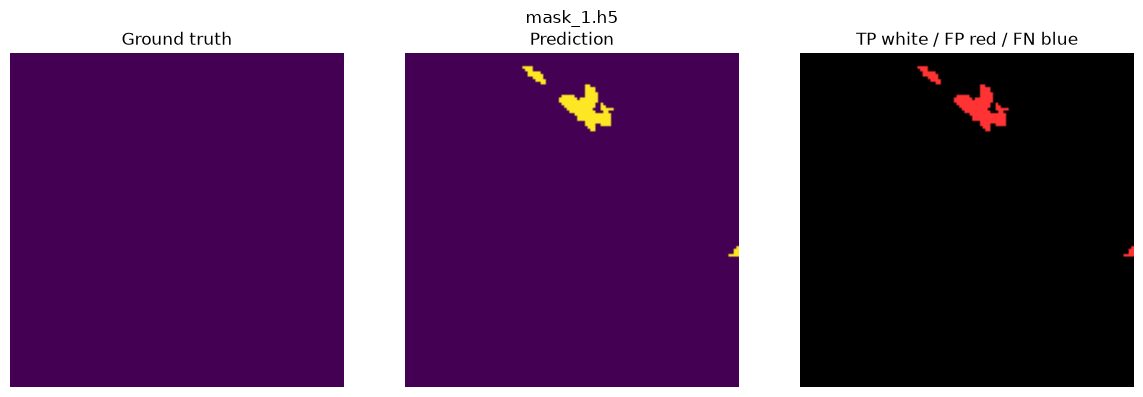

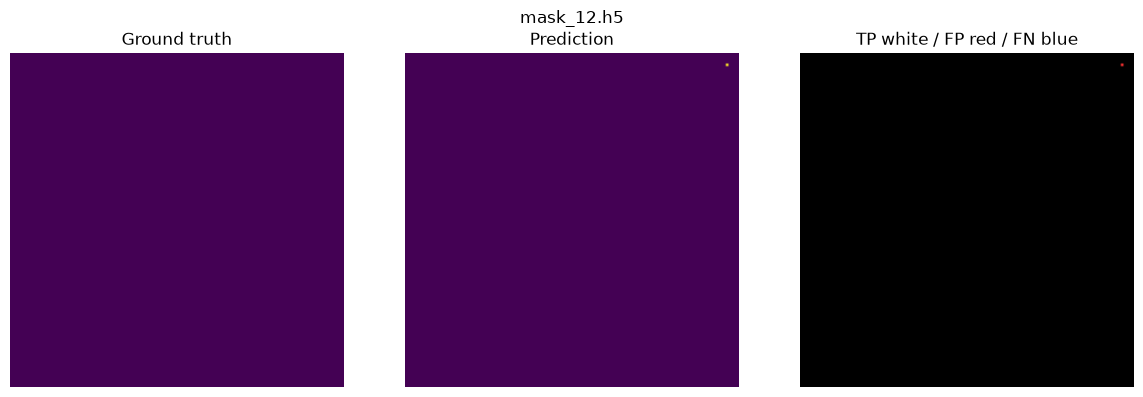

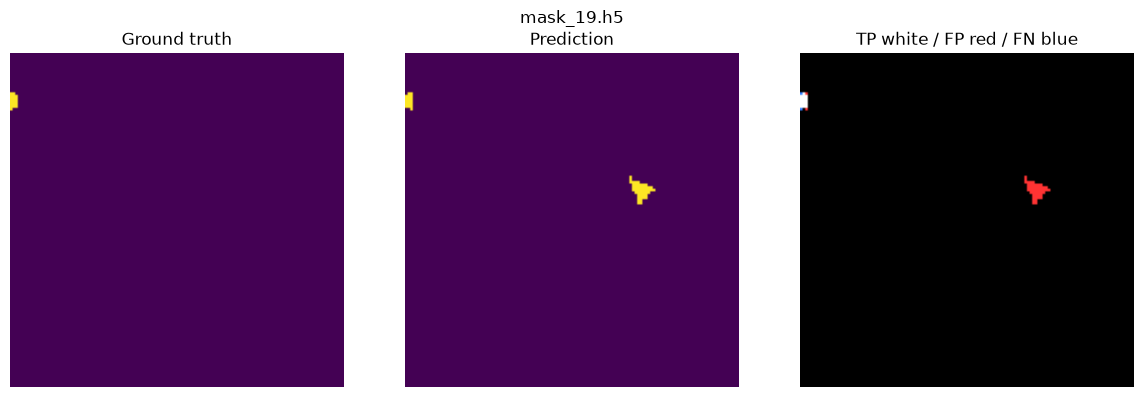

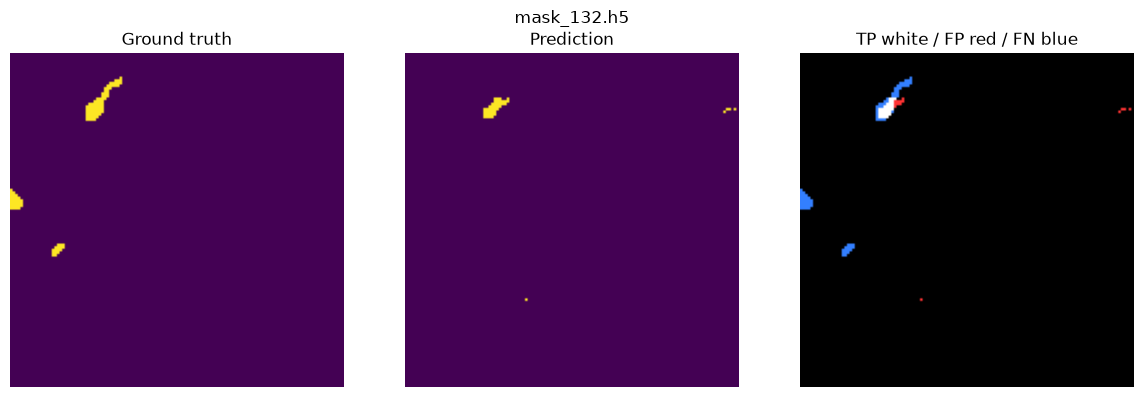

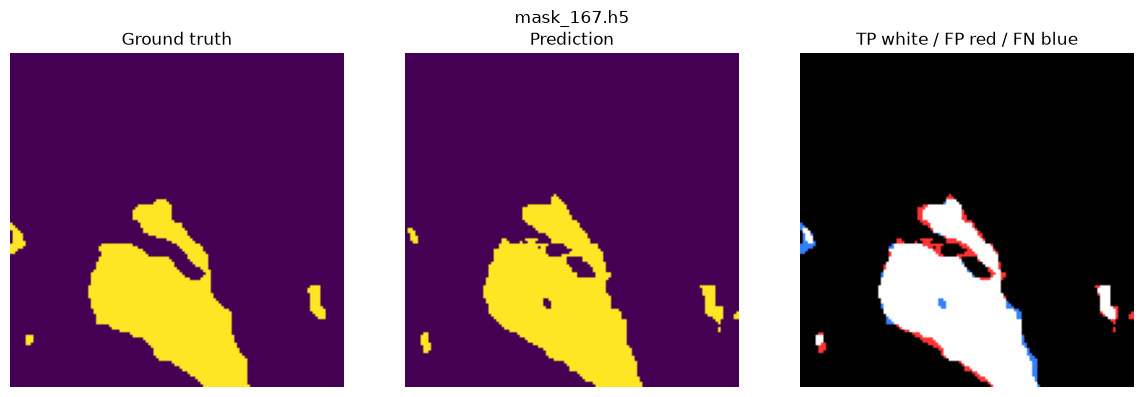

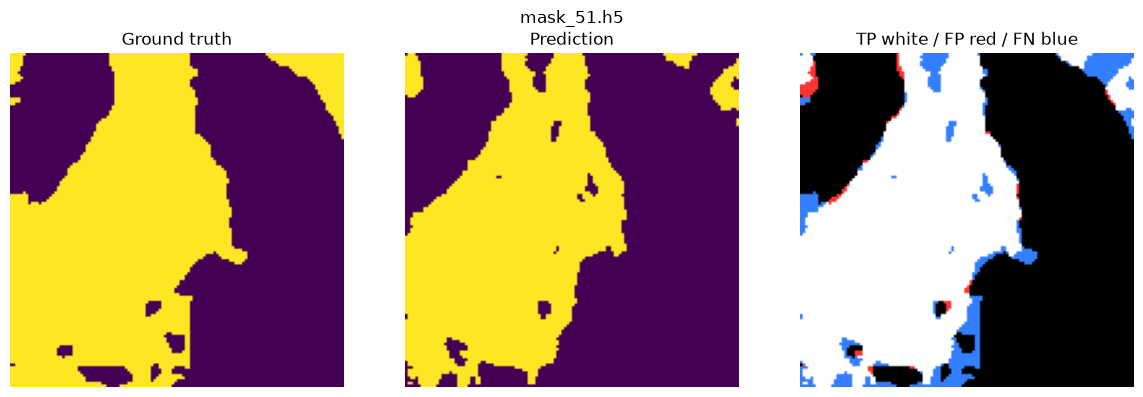

In [18]:

def corresponding_image(mask_name):
    return L4S_IMAGE_DIR / mask_name.replace("mask_", "image_", 1)

def read_image(path):
    with h5py.File(path, "r") as hf:
        if "img" in hf:
            arr = hf["img"][:]
        else:
            arr = hf[list(hf.keys())[0]][:]
    return np.asarray(arr)

def choose_examples(df, n_each=2):
    df = df.dropna(subset=["f1"])
    chosen = []
    chosen += df.nsmallest(n_each, "f1")["mask"].tolist()

    mid = df.iloc[(df["f1"] - df["f1"].median()).abs().argsort()[:n_each]]
    chosen += mid["mask"].tolist()

    chosen += df.nlargest(n_each, "f1")["mask"].tolist()

    # Preserve order, remove duplicates
    return list(dict.fromkeys(chosen))

def show_prediction_example(mask_name, pred_dir, save=True):
    gt = read_mask(L4S_GT_DIR / mask_name)
    pred = read_mask(pred_dir / mask_name)

    err = np.zeros((*gt.shape, 3), dtype=np.float32)
    # TP = white
    tp = (gt == 1) & (pred == 1)
    # FP = red-ish
    fp = (gt == 0) & (pred == 1)
    # FN = blue-ish
    fn = (gt == 1) & (pred == 0)

    err[tp] = [1.0, 1.0, 1.0]
    err[fp] = [1.0, 0.2, 0.2]
    err[fn] = [0.2, 0.5, 1.0]

    fig, axes = plt.subplots(1, 3, figsize=(12,4))
    axes[0].imshow(gt, vmin=0, vmax=1)
    axes[0].set_title("Ground truth")
    axes[1].imshow(pred, vmin=0, vmax=1)
    axes[1].set_title("Prediction")
    axes[2].imshow(err)
    axes[2].set_title("TP white / FP red / FN blue")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(mask_name)
    plt.tight_layout()

    if save:
        plt.savefig(FIGDIR / f"qual_{Path(mask_name).stem}.png", dpi=180, bbox_inches="tight")
    plt.show()

if literal_per_image is not None:
    examples = choose_examples(literal_per_image, n_each=2)
    print("Selected examples:", examples)

    for mask_name in examples:
        show_prediction_example(mask_name, L4S_LITERAL_PRED)


### D1. Plain U-Net vs EfficientNetV2-S qualitative comparison

Showing largest EfficientNet improvements and regressions:
['mask_197.h5', 'mask_72.h5', 'mask_225.h5', 'mask_58.h5', 'mask_234.h5', 'mask_219.h5']


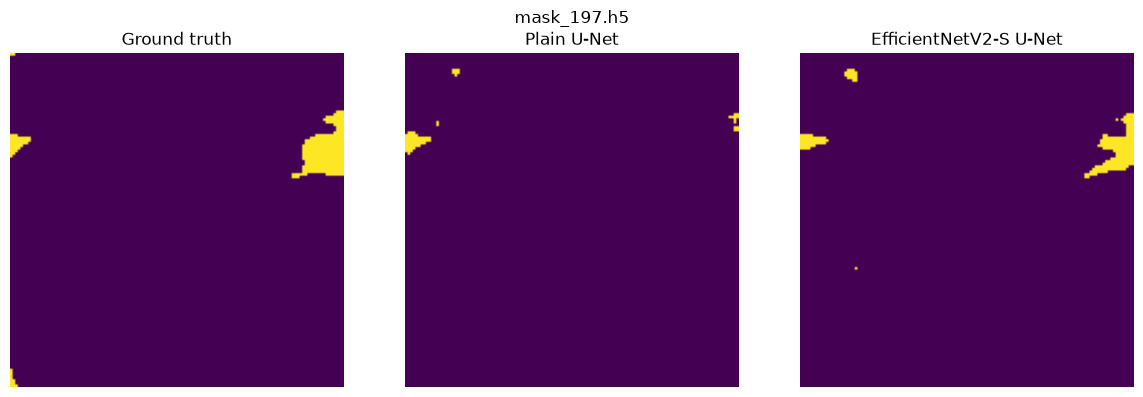

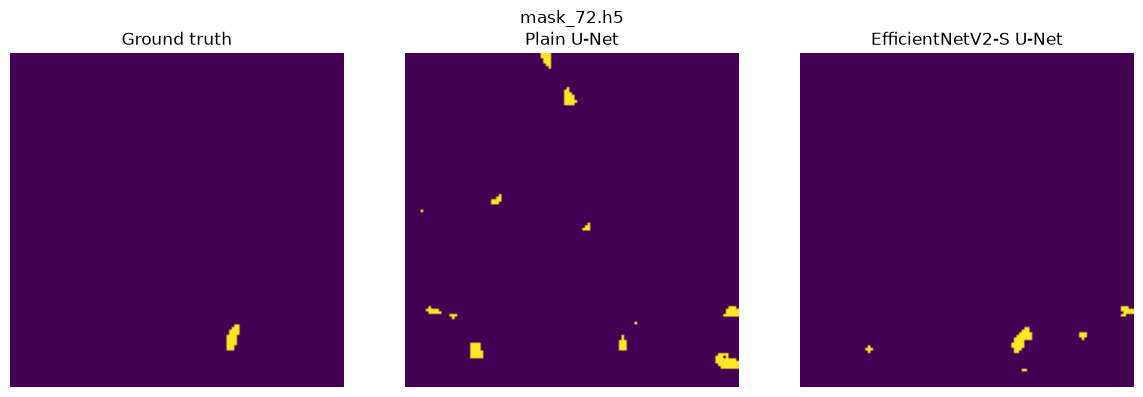

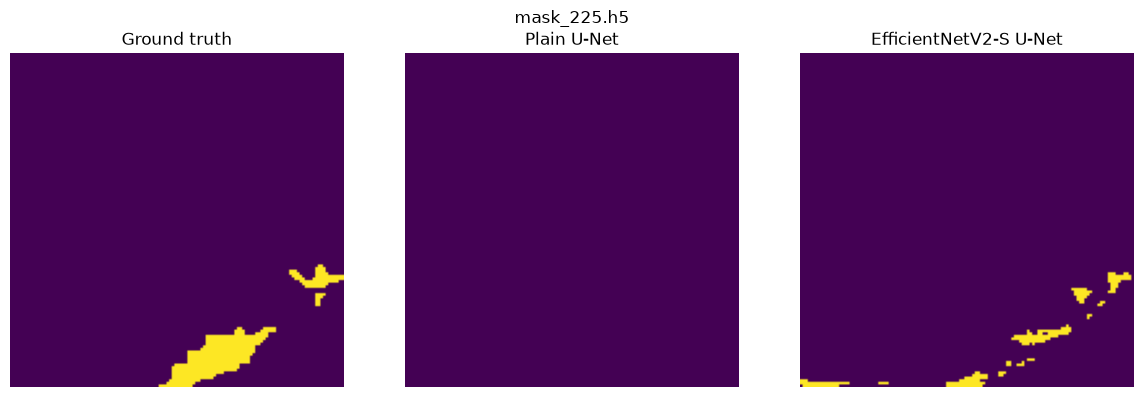

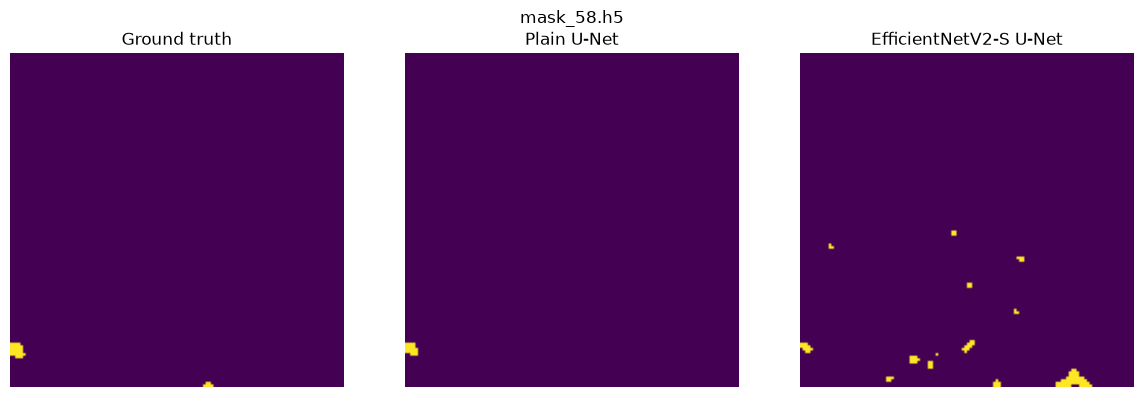

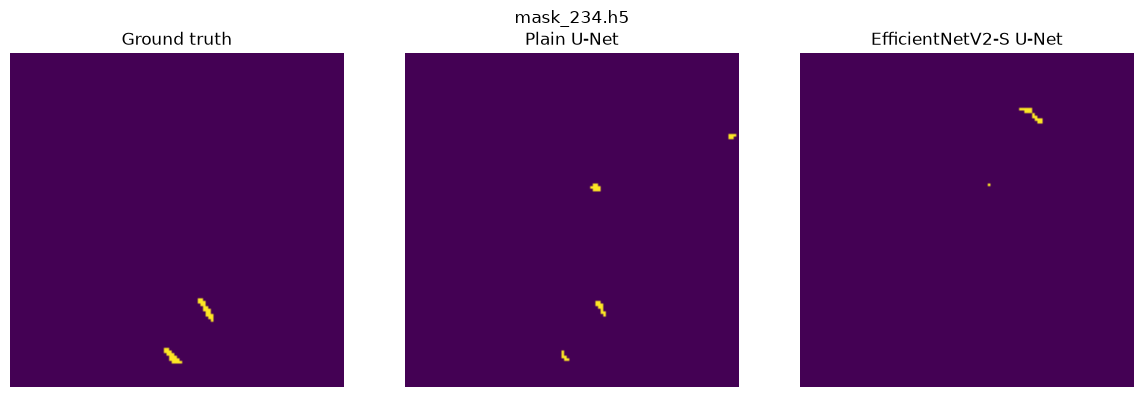

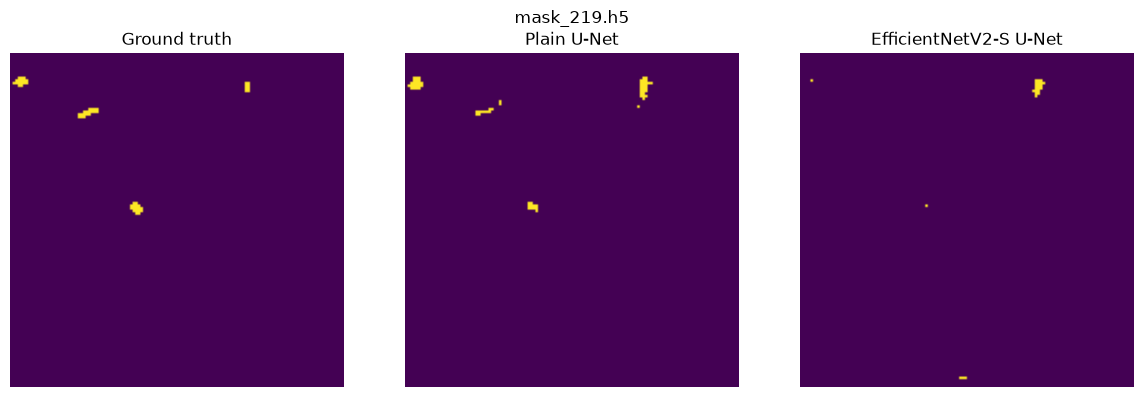

In [19]:

def show_model_comparison(mask_name):
    gt = read_mask(L4S_GT_DIR / mask_name)
    plain = read_mask(L4S_LITERAL_PRED / mask_name)
    eff = read_mask(L4S_EFFICIENTNET_PRED / mask_name)

    fig, axes = plt.subplots(1, 3, figsize=(12,4))
    axes[0].imshow(gt, vmin=0, vmax=1)
    axes[0].set_title("Ground truth")
    axes[1].imshow(plain, vmin=0, vmax=1)
    axes[1].set_title("Plain U-Net")
    axes[2].imshow(eff, vmin=0, vmax=1)
    axes[2].set_title("EfficientNetV2-S U-Net")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(mask_name)
    plt.tight_layout()
    plt.savefig(
        FIGDIR / f"qual_plain_vs_eff_{Path(mask_name).stem}.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

if (
    literal_per_image is not None
    and efficientnet_per_image is not None
    and L4S_LITERAL_PRED.exists()
    and L4S_EFFICIENTNET_PRED.exists()
):
    merged_qual = literal_per_image.merge(
        efficientnet_per_image,
        on="mask",
        suffixes=("_plain","_efficientnet")
    )
    merged_qual["f1_change"] = (
        merged_qual["f1_efficientnet"] - merged_qual["f1_plain"]
    )

    chosen = []
    chosen += merged_qual.nlargest(3, "f1_change")["mask"].tolist()
    chosen += merged_qual.nsmallest(3, "f1_change")["mask"].tolist()
    chosen = list(dict.fromkeys(chosen))

    print("Showing largest EfficientNet improvements and regressions:")
    print(chosen)

    for mask_name in chosen:
        show_model_comparison(mask_name)


### D2. Optional: inspect all 14 input channels for a selected validation image

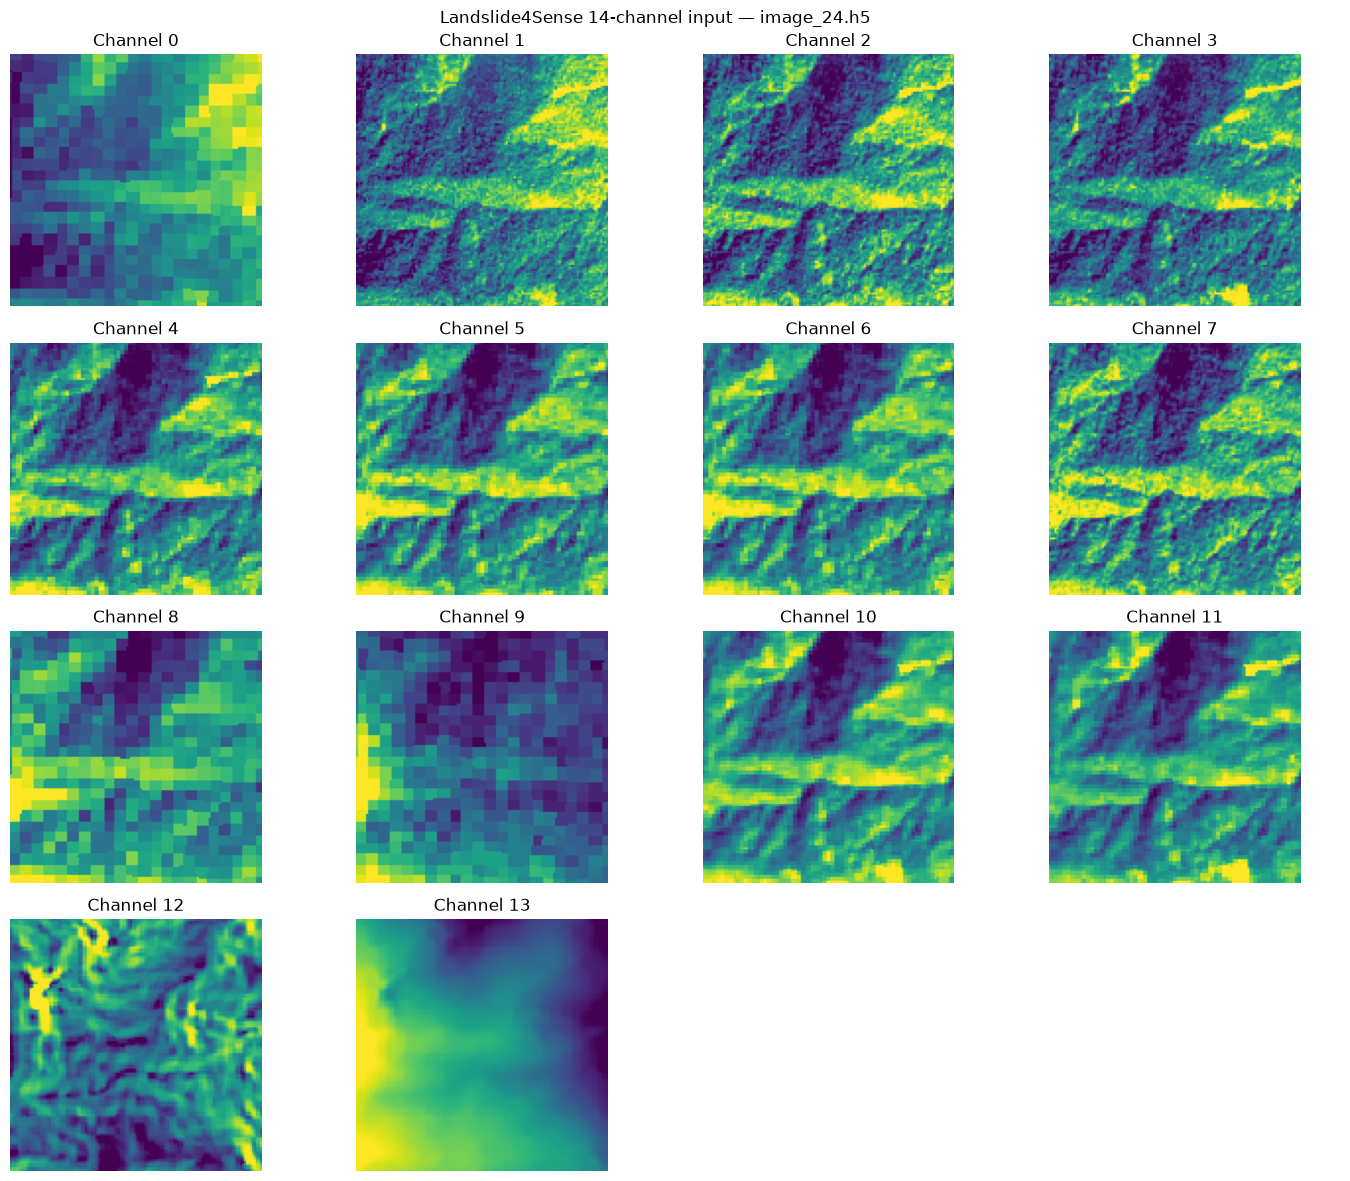

In [20]:

# Landslide4Sense channel semantic names can vary by documentation/version.
# To avoid inventing unsupported names, this notebook labels them Channel 0..13
# unless you replace these labels with the exact dataset documentation.

if literal_per_image is not None and len(literal_per_image):
    mask_name = literal_per_image.dropna(subset=["f1"]).sort_values("f1").iloc[len(literal_per_image)//2]["mask"]
    image_path = corresponding_image(mask_name)

    if image_path.exists():
        image = read_image(image_path)

        # Expect H,W,14 in the public mirror.
        if image.shape[-1] == 14:
            channels = image
        elif image.shape[0] == 14:
            channels = np.moveaxis(image, 0, -1)
        else:
            channels = None

        if channels is not None:
            fig, axes = plt.subplots(4,4, figsize=(14,12))
            axes = axes.ravel()

            for c in range(14):
                x = channels[..., c]
                lo, hi = np.nanpercentile(x, [2,98])
                axes[c].imshow(x, vmin=lo, vmax=hi)
                axes[c].set_title(f"Channel {c}")
                axes[c].axis("off")

            for c in range(14,16):
                axes[c].axis("off")

            fig.suptitle(f"Landslide4Sense 14-channel input — {image_path.name}")
            plt.tight_layout()
            plt.savefig(FIGDIR / "l4s_14channel_example.png", dpi=180, bbox_inches="tight")
            plt.show()



## E. Four representative sample visualizations — input and output

This section adds four representative Landslide4Sense validation samples and shows:

1. a compact **input visualization** using a pseudo-RGB composite from channels 0/1/2,
2. the **ground-truth** landslide mask,
3. the **plain literal-source U-Net** prediction,
4. the **EfficientNetV2-S U-Net** prediction.

Because Landslide4Sense input is 14-channel geospatial data rather than natural RGB imagery, the
input panel is only a visualization aid. It should be interpreted as a display composite, not as
a claim that channels 0/1/2 are the only relevant inputs.


Selected 4 representative samples:
1. mask_197.h5
2. mask_58.h5
3. mask_1.h5
4. mask_229.h5


,mask,plain_f1,efficientnet_f1,f1_change,plain_precision,efficientnet_precision,plain_recall,efficientnet_recall
0,mask_197.h5,0.2476,0.7513,0.5037,0.7183,0.8721,0.1496,0.6598
1,mask_58.h5,0.7636,0.2278,-0.5358,1.0000,0.1452,0.6176,0.5294
2,mask_1.h5,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN
3,mask_229.h5,0.6029,0.4129,-0.1900,0.4519,0.2730,0.9053,0.8463


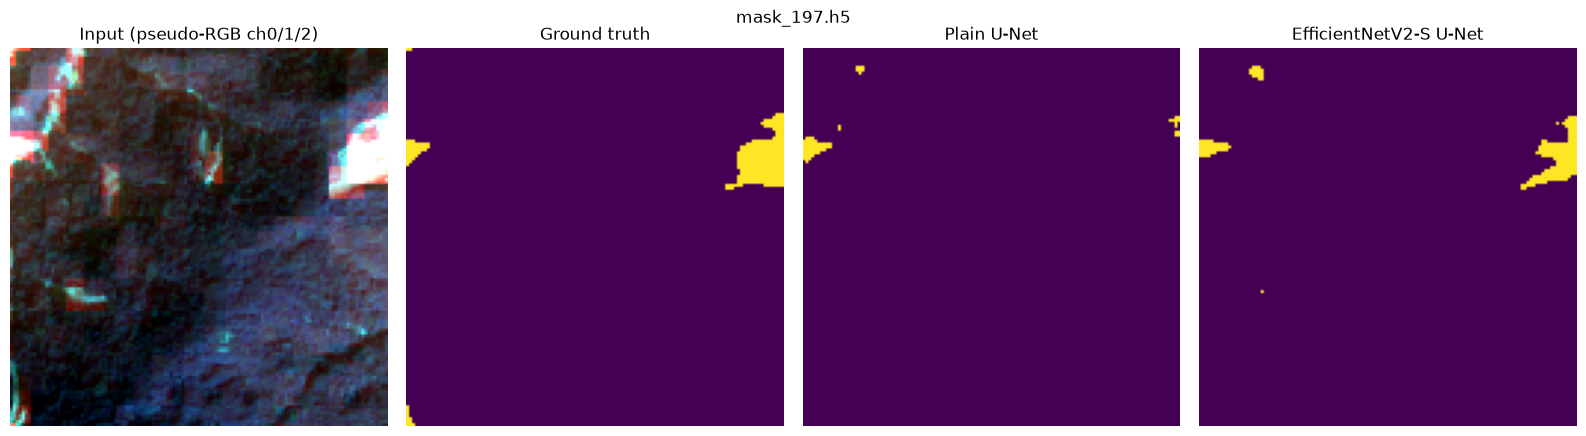

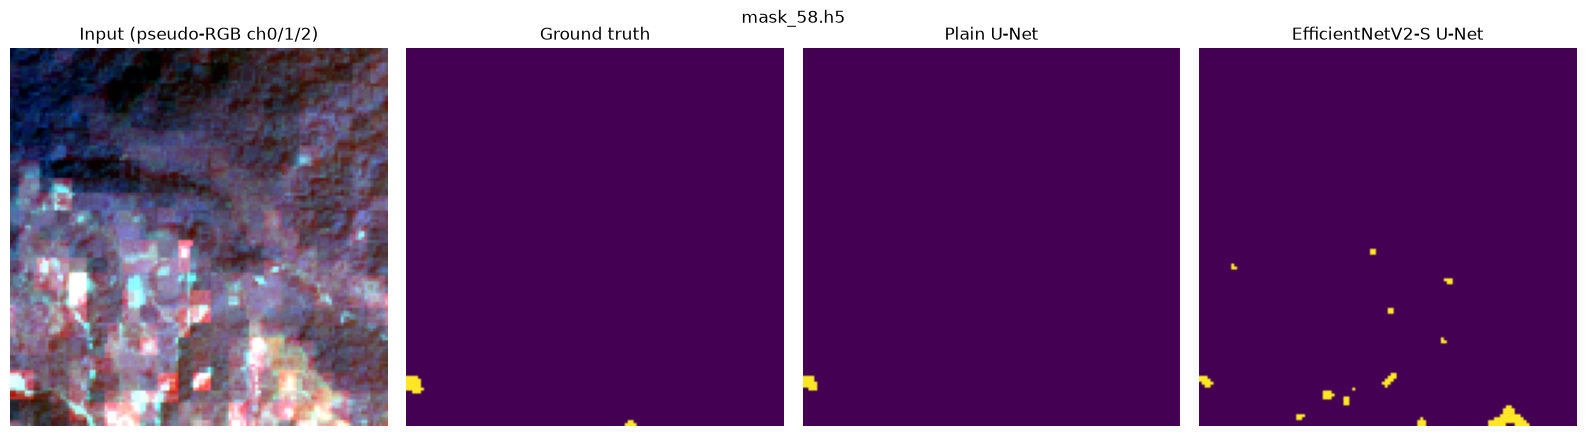

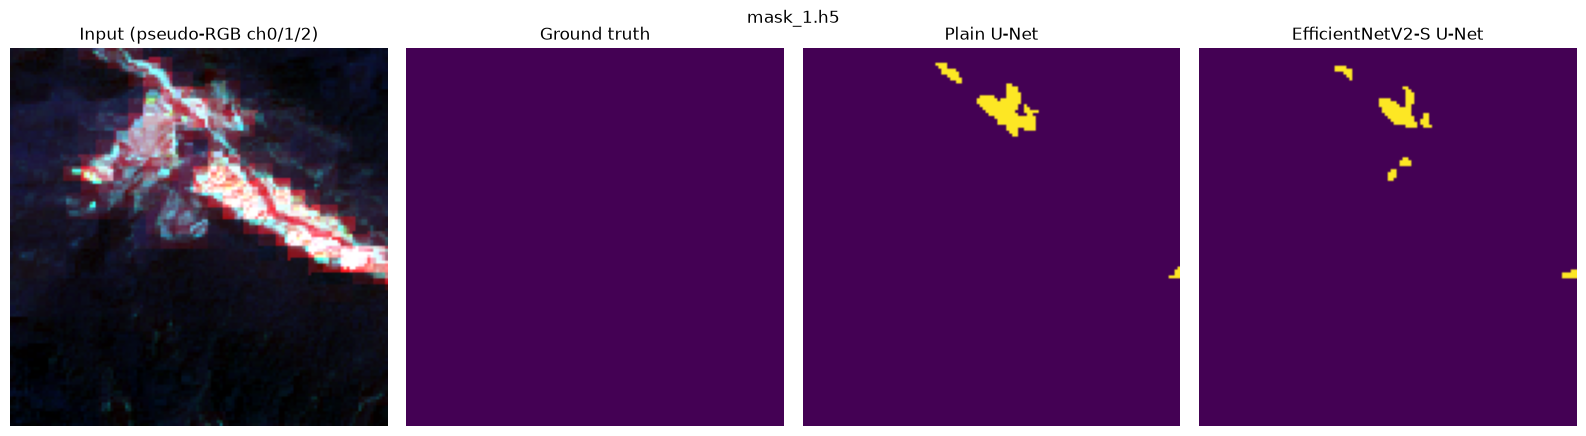

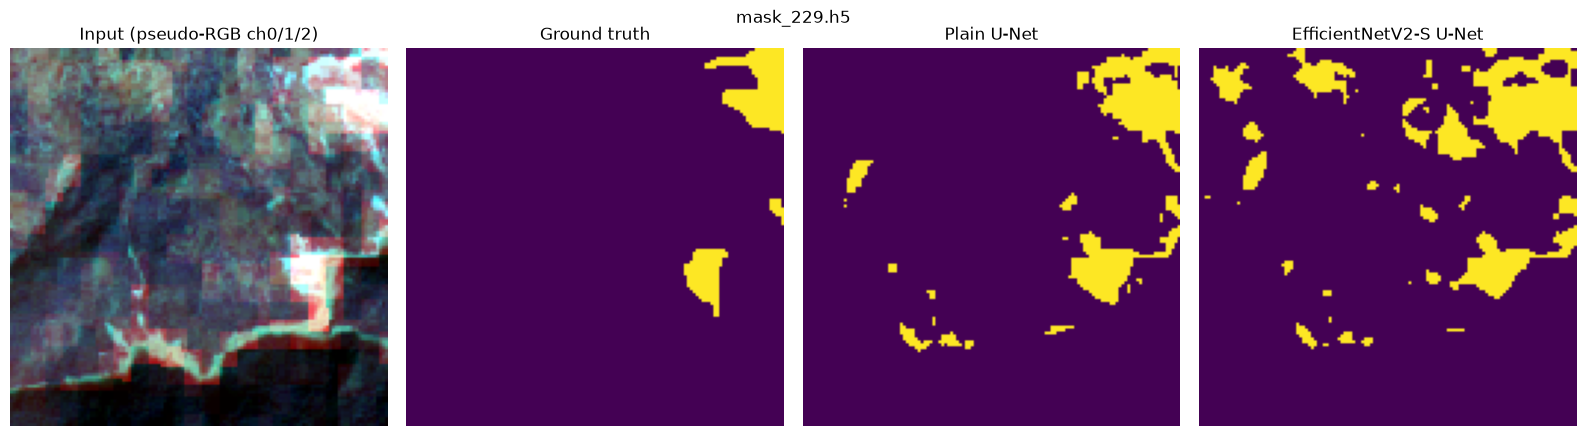

In [21]:

def make_display_composite(image_hwc):
    """
    Build a compact pseudo-RGB visualization from channels 0/1/2.
    This is for display only.
    """
    if image_hwc.ndim != 3:
        raise ValueError(f"Expected HWC image, got {image_hwc.shape}")
    if image_hwc.shape[-1] < 3:
        raise ValueError(f"Need at least 3 channels, got {image_hwc.shape[-1]}")

    rgb = image_hwc[..., :3].astype(np.float32).copy()
    out = np.zeros_like(rgb, dtype=np.float32)

    for c in range(3):
        band = rgb[..., c]
        lo, hi = np.nanpercentile(band, [2, 98])
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            out[..., c] = 0.0
        else:
            out[..., c] = np.clip((band - lo) / (hi - lo), 0.0, 1.0)

    return out

def read_l4s_input_image(image_path):
    arr = read_image(image_path)
    arr = np.asarray(arr)
    if arr.ndim != 3:
        raise RuntimeError(f"{image_path}: expected 3D array, got {arr.shape}")

    if arr.shape[-1] == 14:
        hwc = arr
    elif arr.shape[0] == 14:
        hwc = np.moveaxis(arr, 0, -1)
    else:
        raise RuntimeError(f"{image_path}: cannot identify 14-channel axis: {arr.shape}")

    return hwc

def sample_panel(mask_name):
    image_path = corresponding_image(mask_name)
    img_hwc = read_l4s_input_image(image_path)
    comp = make_display_composite(img_hwc)

    gt = read_mask(L4S_GT_DIR / mask_name)
    plain = read_mask(L4S_LITERAL_PRED / mask_name)
    eff = read_mask(L4S_EFFICIENTNET_PRED / mask_name)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))

    axes[0].imshow(comp)
    axes[0].set_title("Input (pseudo-RGB ch0/1/2)")

    axes[1].imshow(gt, vmin=0, vmax=1)
    axes[1].set_title("Ground truth")

    axes[2].imshow(plain, vmin=0, vmax=1)
    axes[2].set_title("Plain U-Net")

    axes[3].imshow(eff, vmin=0, vmax=1)
    axes[3].set_title("EfficientNetV2-S U-Net")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(mask_name)
    plt.tight_layout()
    plt.savefig(
        FIGDIR / f"sample4_{Path(mask_name).stem}.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

def choose_four_representative_samples():
    if literal_per_image is None or efficientnet_per_image is None:
        return [], None

    merged = literal_per_image.merge(
        efficientnet_per_image,
        on="mask",
        suffixes=("_plain", "_efficientnet"),
    ).dropna(subset=["f1_plain", "f1_efficientnet"]).copy()

    merged["f1_change"] = merged["f1_efficientnet"] - merged["f1_plain"]

    chosen = []
    chosen.append(merged.sort_values("f1_change", ascending=False).iloc[0]["mask"])   # biggest improvement
    chosen.append(merged.sort_values("f1_change", ascending=True).iloc[0]["mask"])    # biggest regression
    chosen.append(merged.sort_values("f1_efficientnet", ascending=True).iloc[0]["mask"])  # hardest EfficientNet case

    med_idx = (merged["f1_efficientnet"] - merged["f1_efficientnet"].median()).abs().sort_values().index[0]
    chosen.append(merged.loc[med_idx, "mask"])  # representative median case

    chosen = list(dict.fromkeys(chosen))
    if len(chosen) < 4:
        for m in merged.sort_values("f1_efficientnet", ascending=False)["mask"].tolist():
            if m not in chosen:
                chosen.append(m)
            if len(chosen) == 4:
                break

    return chosen[:4], merged

four_samples, merged_sample_frame = choose_four_representative_samples()

print("Selected 4 representative samples:")
for i, name in enumerate(four_samples, start=1):
    print(f"{i}. {name}")

if len(four_samples) == 4:
    summary_rows = []
    for name in four_samples:
        row = merged_sample_frame.loc[merged_sample_frame["mask"] == name].iloc[0]
        summary_rows.append({
            "mask": name,
            "plain_f1": row["f1_plain"],
            "efficientnet_f1": row["f1_efficientnet"],
            "f1_change": row["f1_change"],
            "plain_precision": row["precision_plain"],
            "efficientnet_precision": row["precision_efficientnet"],
            "plain_recall": row["recall_plain"],
            "efficientnet_recall": row["recall_efficientnet"],
        })
    display(pd.DataFrame(summary_rows).round(4))

    for mask_name in four_samples:
        sample_panel(mask_name)



### E1. Optional: 4-sample input channel montage

For the same four samples, this optional view shows the 14-channel input as a compact channel montage.
This is heavier visually than the pseudo-RGB view above, but sometimes useful when discussing the
multi-channel nature of Landslide4Sense.


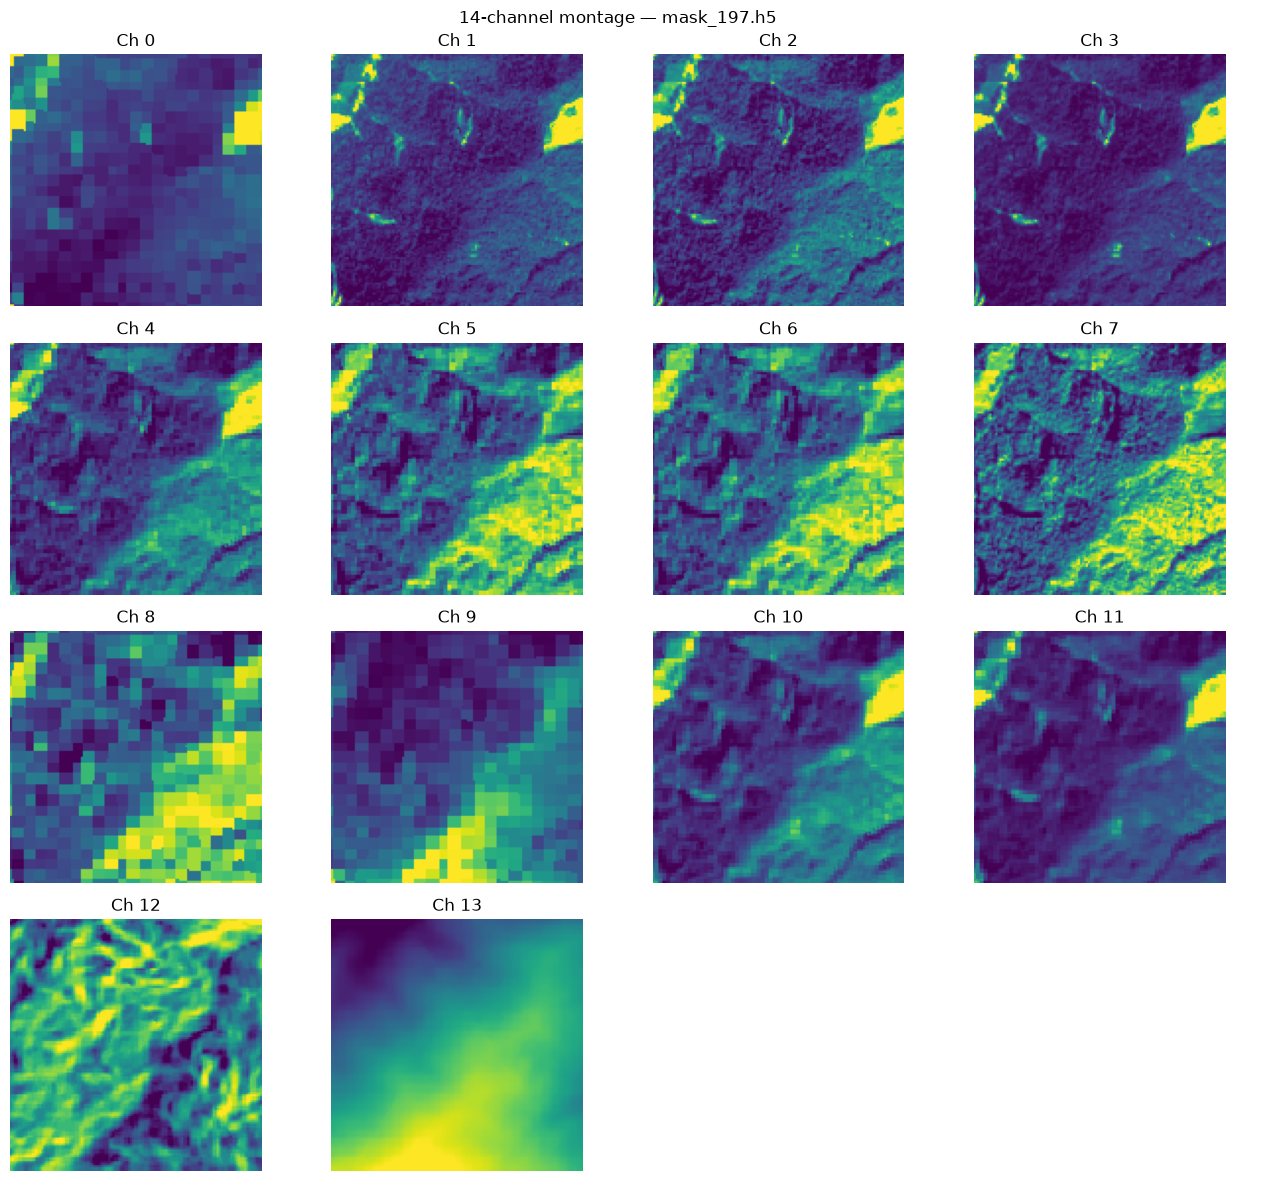

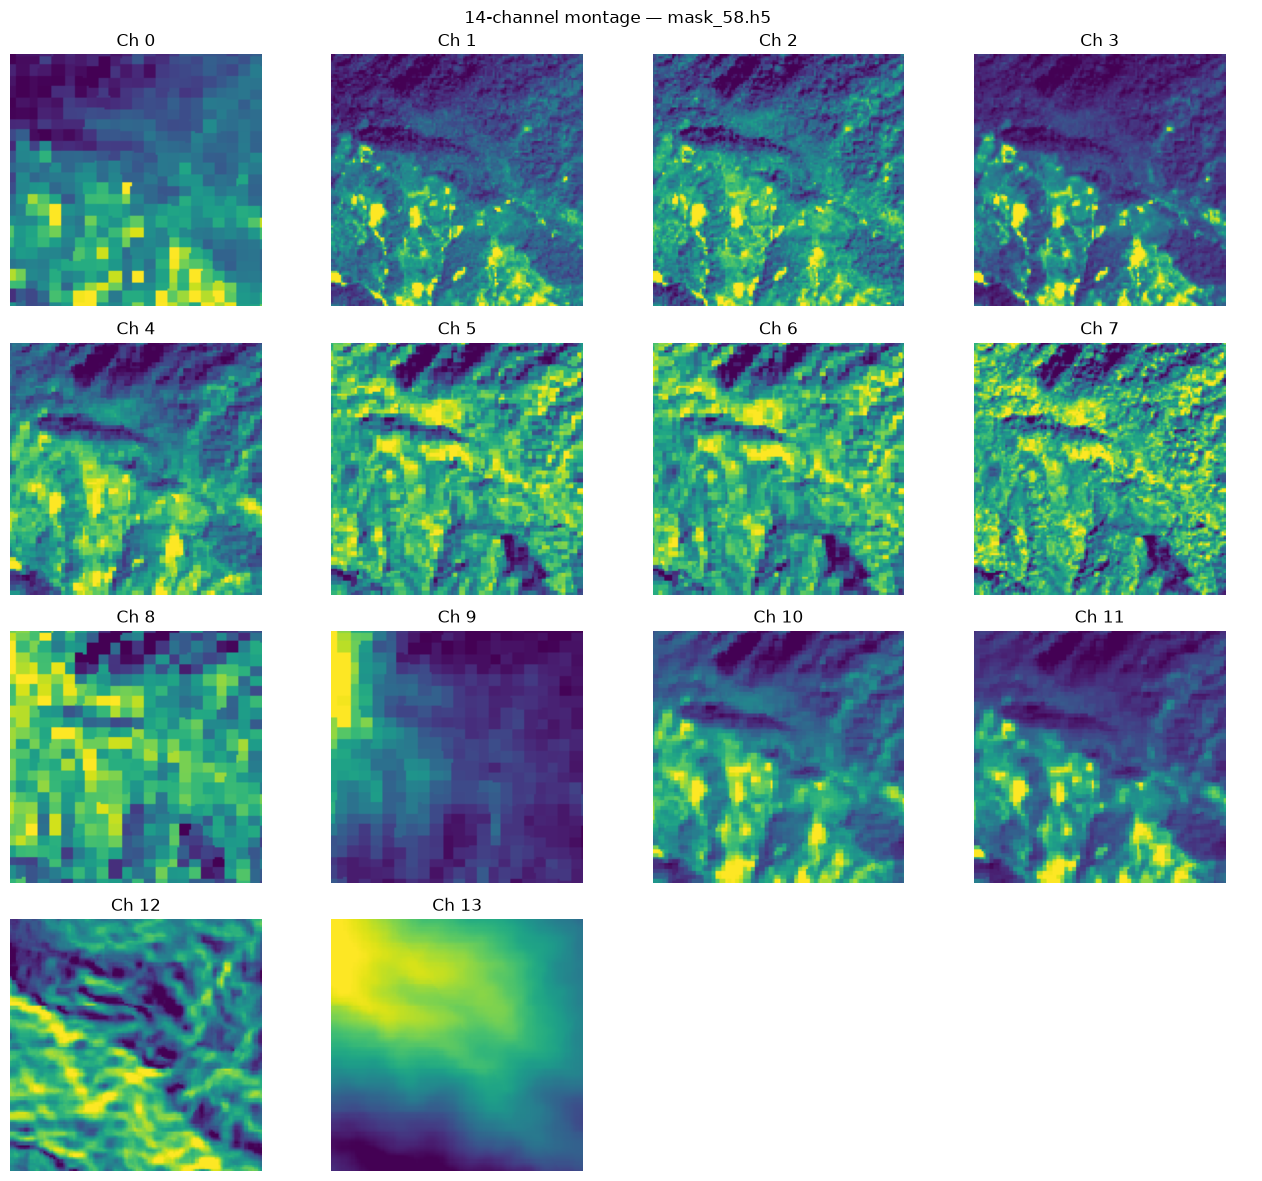

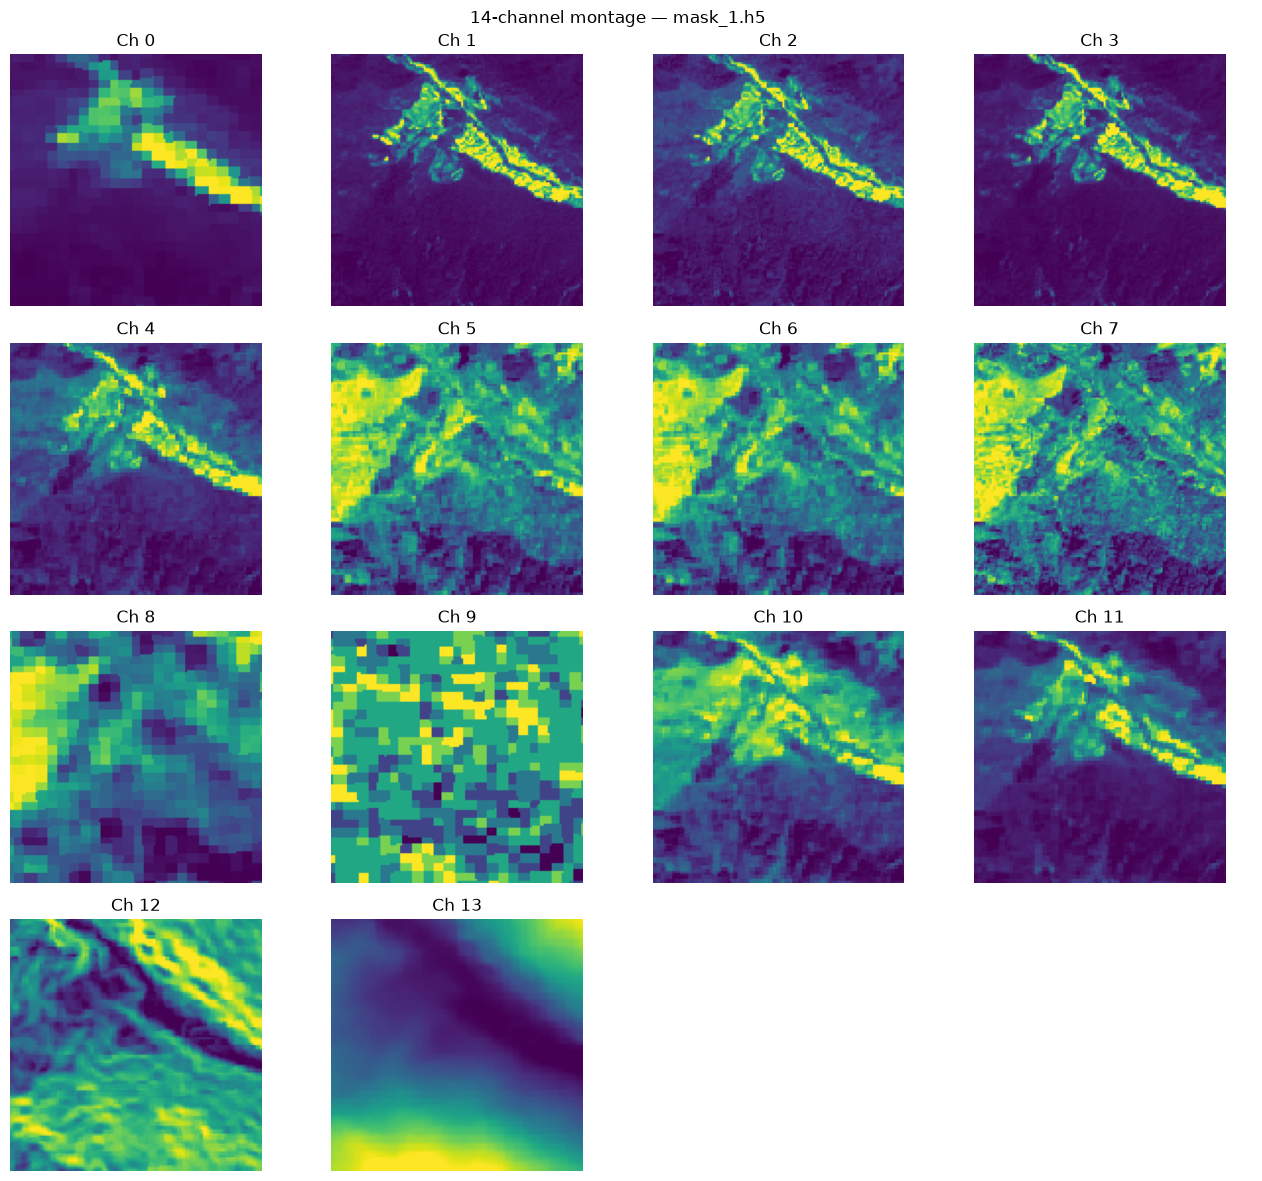

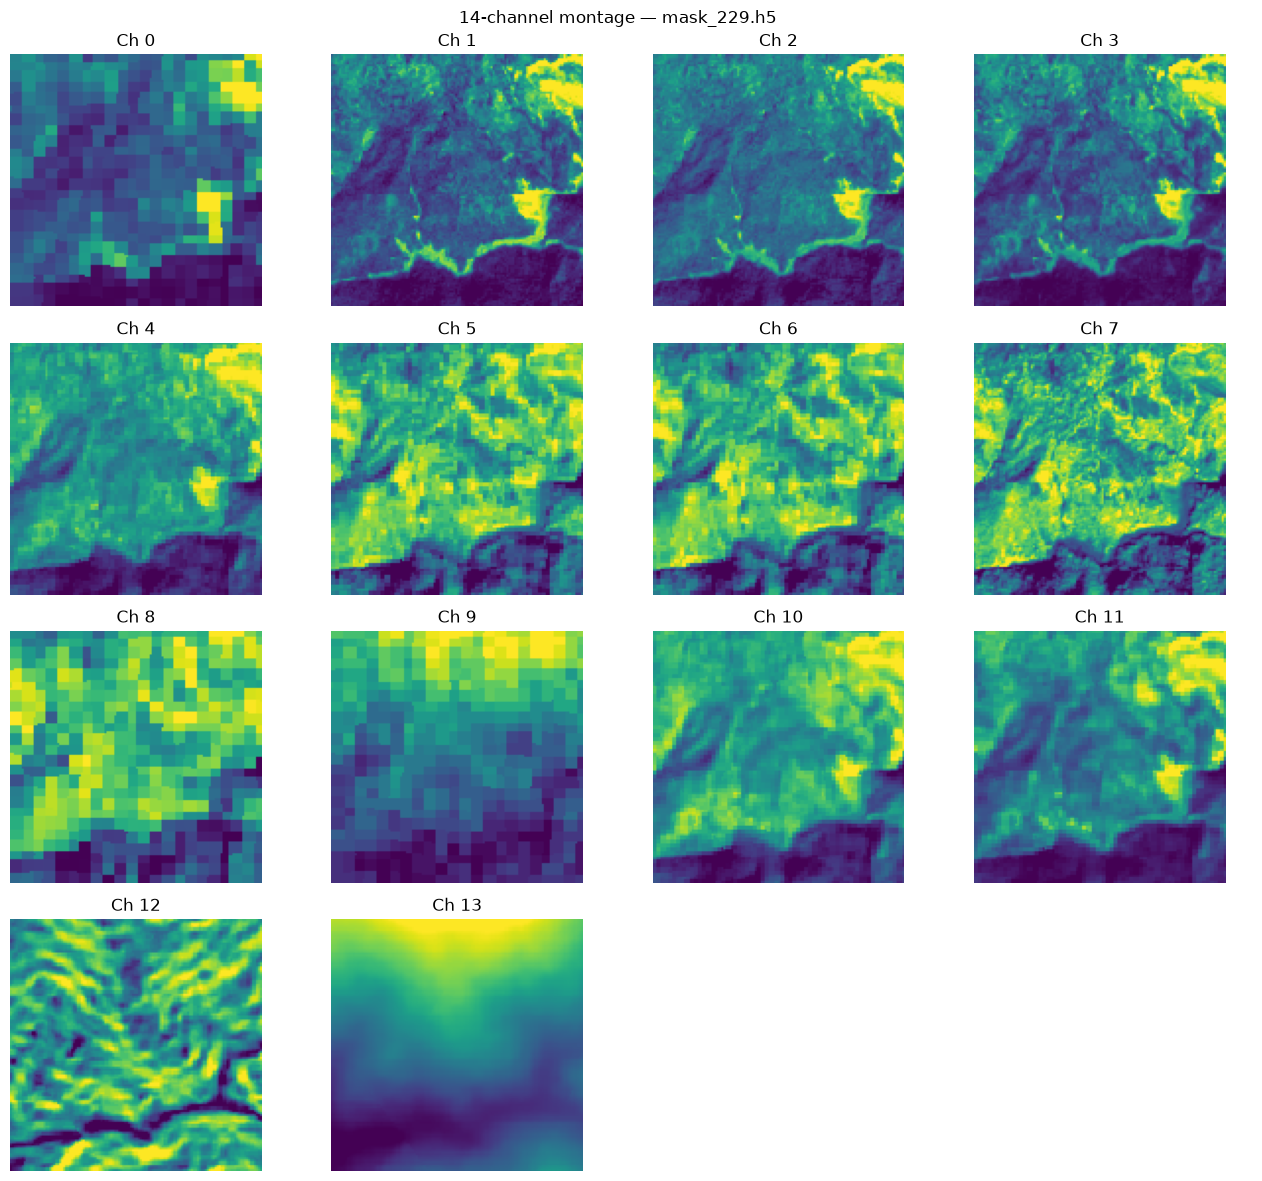

In [22]:

def plot_channel_montage(mask_name):
    image_path = corresponding_image(mask_name)
    img_hwc = read_l4s_input_image(image_path)

    fig, axes = plt.subplots(4, 4, figsize=(13, 12))
    axes = axes.ravel()

    for c in range(14):
        band = img_hwc[..., c]
        lo, hi = np.nanpercentile(band, [2, 98])
        axes[c].imshow(band, vmin=lo, vmax=hi)
        axes[c].set_title(f"Ch {c}")
        axes[c].axis("off")

    for c in range(14, 16):
        axes[c].axis("off")

    fig.suptitle(f"14-channel montage — {mask_name}")
    plt.tight_layout()
    plt.savefig(
        FIGDIR / f"montage14_{Path(mask_name).stem}.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

for mask_name in four_samples:
    plot_channel_montage(mask_name)


## F. Prediction agreement between Landslide4Sense models

In [23]:

def prediction_agreement(dir_a, dir_b):
    files_a = {p.name:p for p in dir_a.glob("mask_*.h5")}
    files_b = {p.name:p for p in dir_b.glob("mask_*.h5")}
    names = sorted(set(files_a) & set(files_b), key=lambda x: int("".join(c for c in Path(x).stem if c.isdigit())))

    total = equal = a_pos_b_neg = a_neg_b_pos = both_pos = 0

    for name in names:
        a = read_mask(files_a[name])
        b = read_mask(files_b[name])

        total += a.size
        equal += int((a == b).sum())
        both_pos += int(((a == 1) & (b == 1)).sum())
        a_pos_b_neg += int(((a == 1) & (b == 0)).sum())
        a_neg_b_pos += int(((a == 0) & (b == 1)).sum())

    return {
        "common_files": len(names),
        "pixel_agreement": equal / total if total else np.nan,
        "pixel_disagreement": 1 - equal / total if total else np.nan,
        "both_positive": both_pos,
        "reported_pos_literal_neg": a_pos_b_neg,
        "reported_neg_literal_pos": a_neg_b_pos,
    }

if L4S_REPORTED_PRED.exists() and L4S_LITERAL_PRED.exists():
    agree = prediction_agreement(L4S_REPORTED_PRED, L4S_LITERAL_PRED)
    display(pd.Series(agree))


print()
print("Plain literal-source vs EfficientNetV2-S:")
if L4S_LITERAL_PRED.exists() and L4S_EFFICIENTNET_PRED.exists():
    agree_plain_eff = prediction_agreement(L4S_LITERAL_PRED, L4S_EFFICIENTNET_PRED)
    display(pd.Series(agree_plain_eff))


common_files                  245.000000
pixel_agreement                 0.992709
pixel_disagreement              0.007291
both_positive               57640.000000
reported_pos_literal_neg     3928.000000
reported_neg_literal_pos    25340.000000
dtype: float64


Plain literal-source vs EfficientNetV2-S:


common_files                  245.0000
pixel_agreement                 0.9915
pixel_disagreement              0.0085
both_positive               57302.0000
reported_pos_literal_neg    25678.0000
reported_neg_literal_pos     8442.0000
dtype: float64

## G. Tillamook — frozen development results

In [24]:

comparison_path = TILLAMOOK_PHASE4 / "comparison.csv"

if comparison_path.exists():
    till = pd.read_csv(comparison_path).sort_values("dice", ascending=False).reset_index(drop=True)
else:
    # Fallback to the measured results currently recorded in the project notes.
    till = pd.DataFrame([
        {"run":"deep_7ch","architecture":"deep","features":"7ch","parameters":7767137,"best_epoch":21,"threshold":0.45,
         "dice":0.4085,"iou":0.2567,"precision":0.2961,"recall":0.6584,"specificity":0.7396,
         "fp":13034704,"fn":2844173,"predicted_positive_fraction":0.3171,"gt_positive_fraction":0.1426},
        {"run":"deep_3ch","architecture":"deep","features":"3ch","parameters":7765985,"best_epoch":26,"threshold":0.50,
         "dice":0.3434,"iou":0.2073,"precision":0.2327,"recall":0.6543,"specificity":0.6412,
         "fp":17962608,"fn":2878302,"predicted_positive_fraction":0.4009,"gt_positive_fraction":0.1426},
        {"run":"shallow_7ch","architecture":"shallow","features":"7ch","parameters":468961,"best_epoch":21,"threshold":0.50,
         "dice":0.3228,"iou":0.1924,"precision":0.2105,"recall":0.6919,"specificity":0.5683,
         "fp":21611982,"fn":2565382,"predicted_positive_fraction":0.4688,"gt_positive_fraction":0.1426},
        {"run":"shallow_3ch","architecture":"shallow","features":"3ch","parameters":467809,"best_epoch":4,"threshold":0.45,
         "dice":0.2901,"iou":0.1696,"precision":0.1826,"recall":0.7051,"specificity":0.4750,
         "fp":26286768,"fn":2455430,"predicted_positive_fraction":0.5507,"gt_positive_fraction":0.1426},
    ])

display(till.round(4))


,run,architecture,features,parameters,best_epoch,threshold,dice,iou,precision,recall,specificity,fp,fn,gt_positive_fraction,predicted_positive_fraction,pos_weight
0,deep_7ch,Deep,7ch,7767137,21,0.45,0.4085,0.2567,0.2961,0.6584,0.7396,13034704,2844173,0.1426,0.3171,4.5964
1,deep_3ch,Deep,3ch,7765985,26,0.50,0.3434,0.2073,0.2327,0.6543,0.6412,17962608,2878302,0.1426,0.4009,4.5964
2,shallow_7ch,Shallow,7ch,468961,21,0.50,0.3228,0.1924,0.2105,0.6919,0.5683,21611982,2565382,0.1426,0.4688,4.5964
3,shallow_3ch,Shallow,3ch,467809,4,0.45,0.2901,0.1696,0.1826,0.7051,0.4750,26286768,2455430,0.1426,0.5507,4.5964


### F1. 2×2 metric comparison

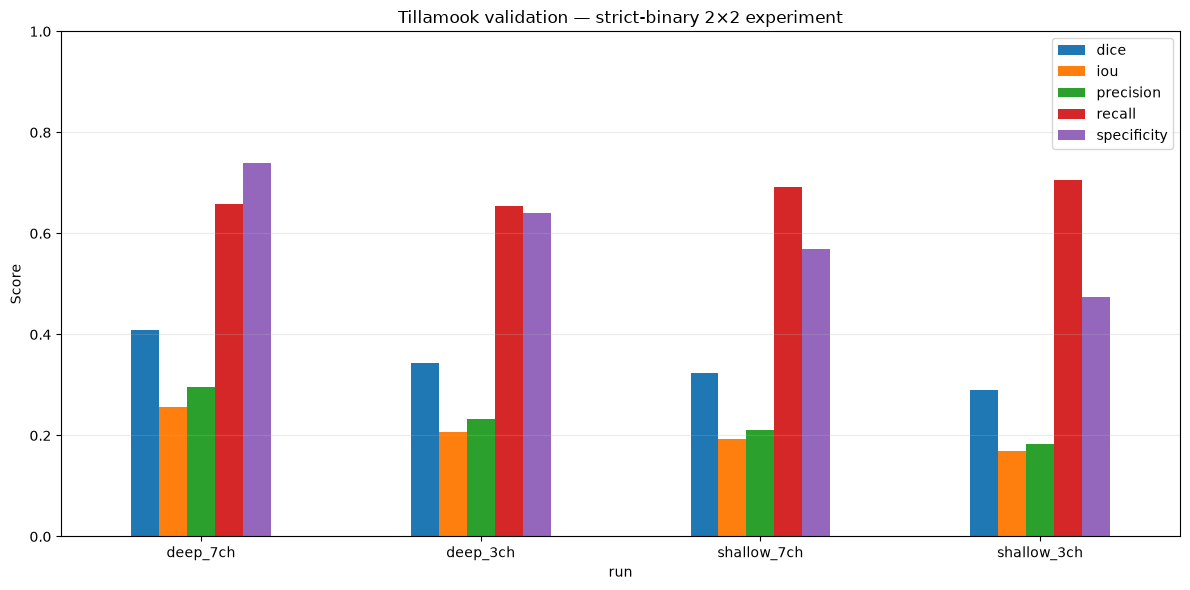

In [25]:

metric_cols = ["dice","iou","precision","recall","specificity"]

ax = till.set_index("run")[metric_cols].plot(kind="bar", figsize=(12,6), rot=0)
ax.set_title("Tillamook validation — strict-binary 2×2 experiment")
ax.set_ylabel("Score")
ax.set_ylim(0,1)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR / "tillamook_2x2_metrics.png", dpi=180, bbox_inches="tight")
plt.show()


### F2. GT-positive vs predicted-positive area

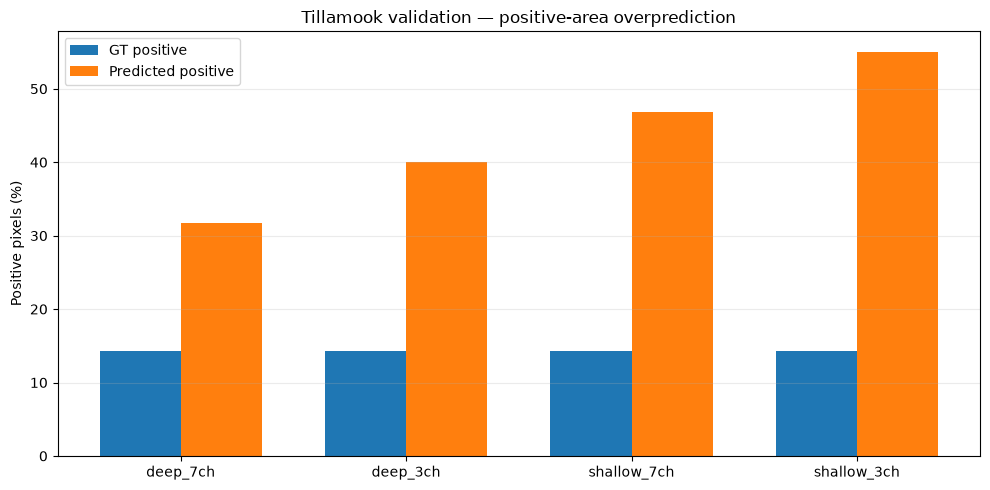

,run,gt_positive_fraction,predicted_positive_fraction,overprediction_ratio
0,deep_7ch,0.143,0.317,2.224
1,deep_3ch,0.143,0.401,2.811
2,shallow_7ch,0.143,0.469,3.287
3,shallow_3ch,0.143,0.551,3.862


In [26]:

if "gt_positive_fraction" in till.columns and "predicted_positive_fraction" in till.columns:
    x = np.arange(len(till))
    w = 0.36

    fig, ax = plt.subplots(figsize=(10,5))
    ax.bar(x-w/2, 100*till["gt_positive_fraction"], width=w, label="GT positive")
    ax.bar(x+w/2, 100*till["predicted_positive_fraction"], width=w, label="Predicted positive")
    ax.set_xticks(x)
    ax.set_xticklabels(till["run"])
    ax.set_ylabel("Positive pixels (%)")
    ax.set_title("Tillamook validation — positive-area overprediction")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGDIR / "tillamook_positive_area.png", dpi=180, bbox_inches="tight")
    plt.show()

    over = till[["run","gt_positive_fraction","predicted_positive_fraction"]].copy()
    over["overprediction_ratio"] = over["predicted_positive_fraction"] / over["gt_positive_fraction"]
    display(over.round(3))


### F3. FP / FN burden

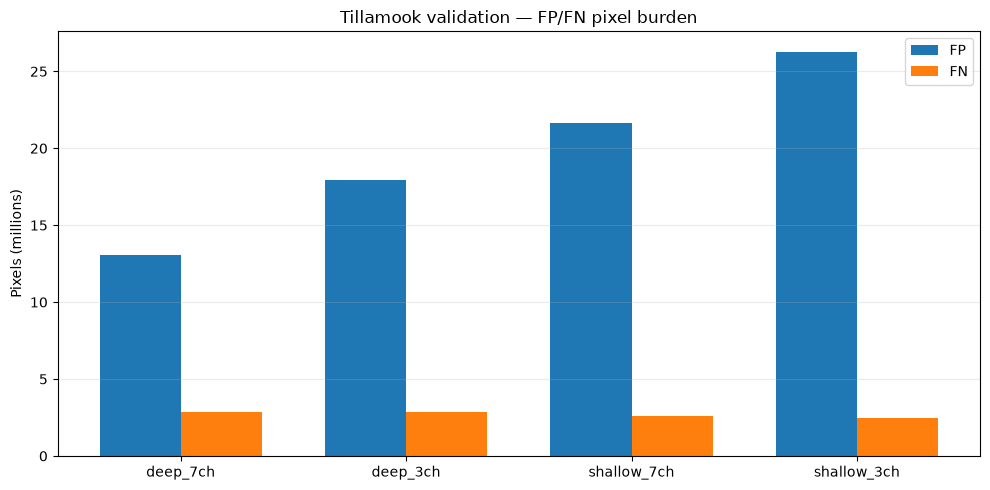

In [27]:

if {"fp","fn"} <= set(till.columns):
    x = np.arange(len(till))
    w = 0.36

    fig, ax = plt.subplots(figsize=(10,5))
    ax.bar(x-w/2, till["fp"]/1e6, width=w, label="FP")
    ax.bar(x+w/2, till["fn"]/1e6, width=w, label="FN")
    ax.set_xticks(x)
    ax.set_xticklabels(till["run"])
    ax.set_ylabel("Pixels (millions)")
    ax.set_title("Tillamook validation — FP/FN pixel burden")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGDIR / "tillamook_fp_fn.png", dpi=180, bbox_inches="tight")
    plt.show()


## H. Tillamook — training histories

In [28]:

till_hist = {}

for name, run_dir in TILLAMOOK_RUNS.items():
    p = run_dir / "history.csv"
    if p.exists():
        till_hist[name] = pd.read_csv(p)
        print(name, till_hist[name].shape)
    else:
        print("Missing history:", p)


shallow_7ch (50, 15)
shallow_3ch (50, 15)
deep_7ch (50, 15)
deep_3ch (50, 15)


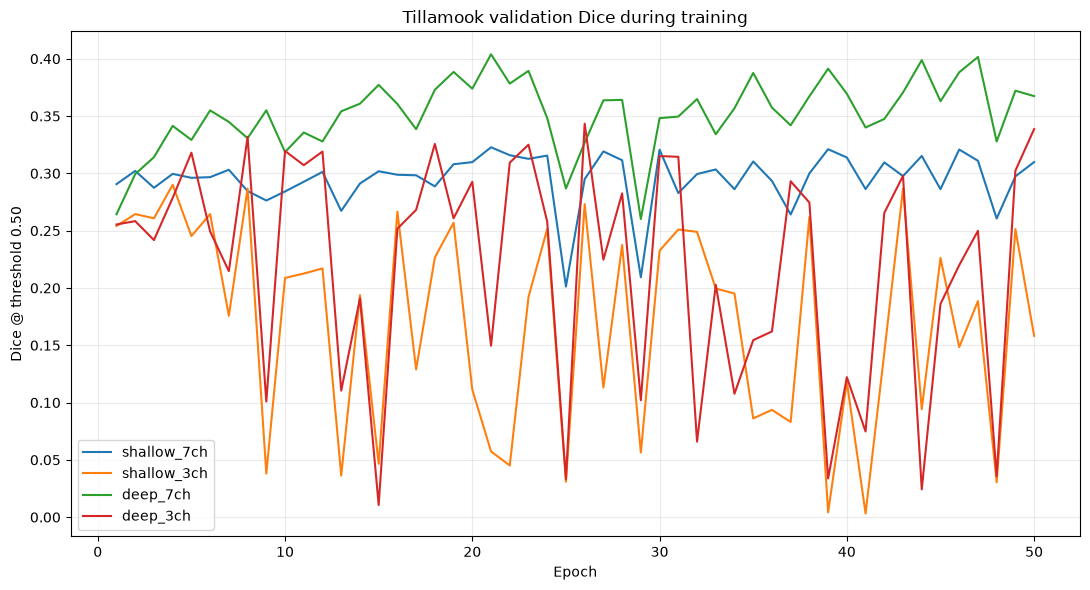

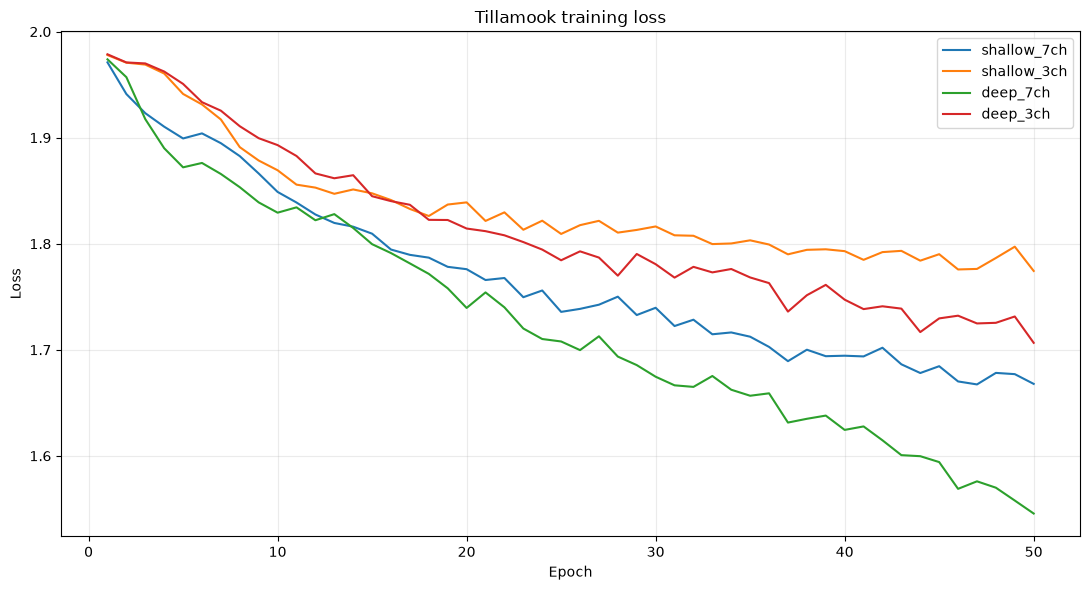

In [29]:

if till_hist:
    fig, ax = plt.subplots(figsize=(11,6))
    for name, h in till_hist.items():
        possible = [c for c in h.columns if "validation" in c.lower() and "dice" in c.lower()]
        if possible:
            ax.plot(h["epoch"], h[possible[0]], label=name)

    ax.set_title("Tillamook validation Dice during training")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Dice @ threshold 0.50")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGDIR / "tillamook_training_val_dice.png", dpi=180, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(11,6))
    for name, h in till_hist.items():
        if "train_loss" in h:
            ax.plot(h["epoch"], h["train_loss"], label=name)

    ax.set_title("Tillamook training loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGDIR / "tillamook_training_loss.png", dpi=180, bbox_inches="tight")
    plt.show()


## I. Tillamook — threshold sweeps

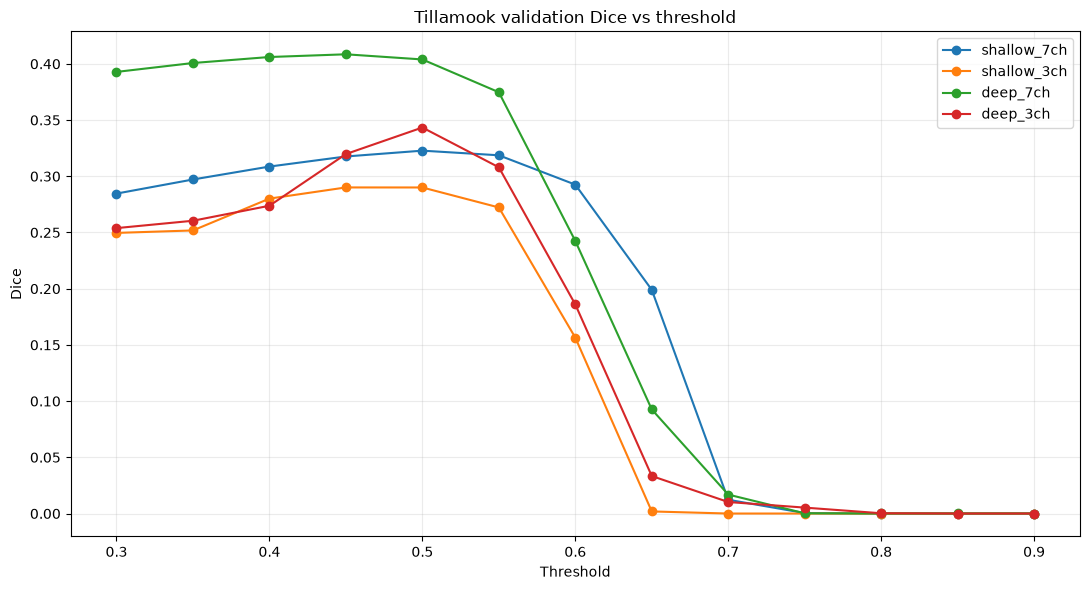

In [30]:

sweeps = {}

for name, run_dir in TILLAMOOK_RUNS.items():
    p = run_dir / "validation_threshold_sweep.csv"
    if p.exists():
        sweeps[name] = pd.read_csv(p)

if sweeps:
    fig, ax = plt.subplots(figsize=(11,6))
    for name, s in sweeps.items():
        ax.plot(s["threshold"], s["dice"], marker="o", label=name)

    ax.set_title("Tillamook validation Dice vs threshold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Dice")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGDIR / "tillamook_threshold_dice.png", dpi=180, bbox_inches="tight")
    plt.show()


### H1. Deep 7ch operating-point trade-off

,threshold,dice,iou,precision,recall,specificity,gt_positive_fraction,predicted_positive_fraction,fp,fn
0,0.30,0.3928,0.2444,0.2599,0.8038,0.6194,0.1426,0.4410,19056625,1634054
1,0.35,0.4007,0.2506,0.2720,0.7609,0.6612,0.1426,0.3990,16960360,1990657
2,0.40,0.4061,0.2548,0.2835,0.7151,0.6995,0.1426,0.3596,15045267,2372648
3,0.45,0.4085,0.2567,0.2961,0.6584,0.7396,0.1426,0.3171,13034704,2844173
4,0.50,0.4039,0.2531,0.3114,0.5746,0.7887,0.1426,0.2631,10580399,3542390
5,0.55,0.3747,0.2306,0.3321,0.4300,0.8561,0.1426,0.1847,7203212,4746140
6,0.60,0.2425,0.1380,0.3470,0.1863,0.9417,0.1426,0.0766,2919381,6775487
7,0.65,0.0926,0.0485,0.3587,0.0532,0.9842,0.1426,0.0211,791424,7884443
8,0.70,0.0169,0.0085,0.3693,0.0086,0.9976,0.1426,0.0033,122627,8255267
9,0.75,0.0002,0.0001,0.3187,0.0001,1.0000,0.1426,0.0000,1836,8326212


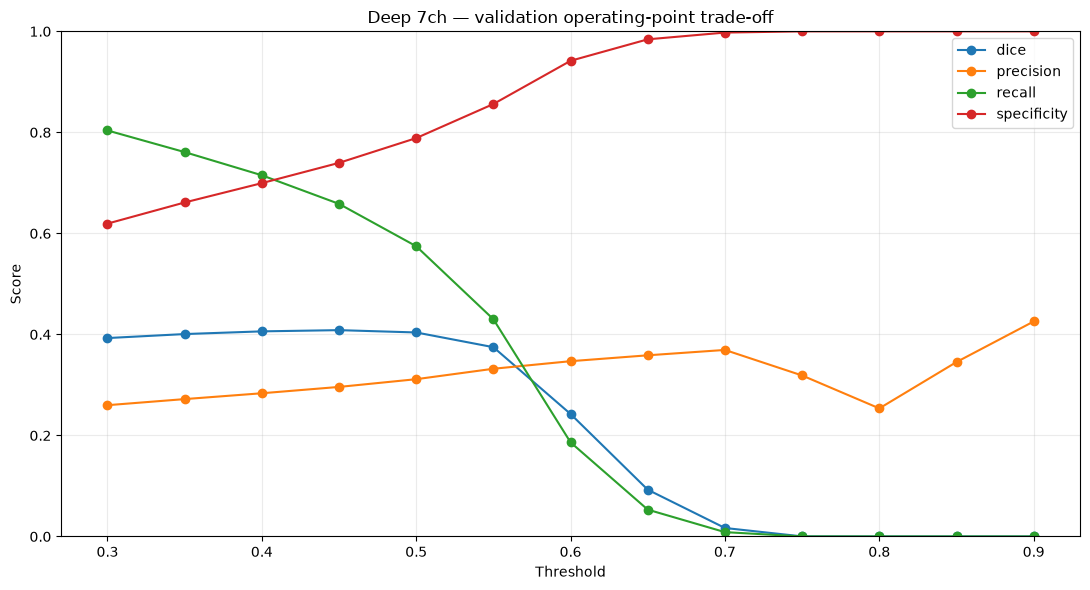

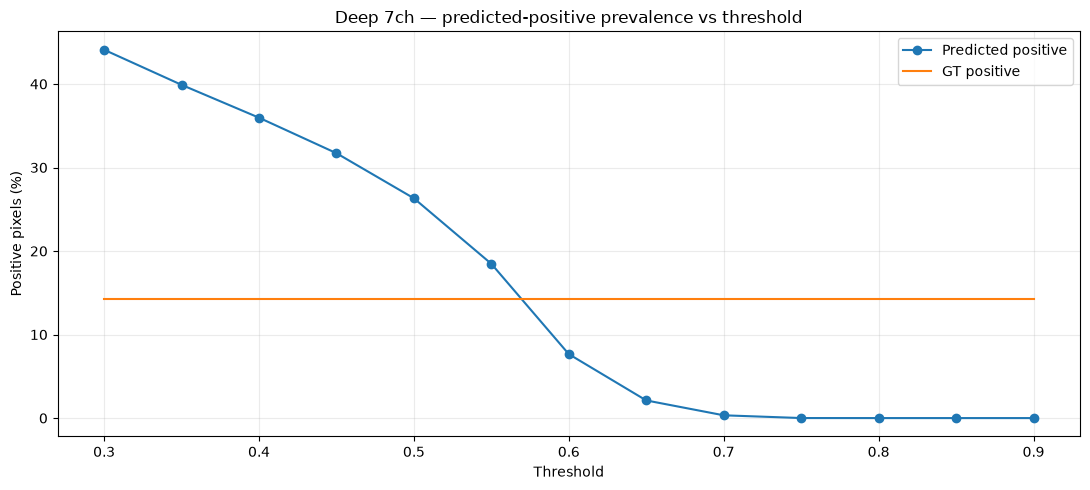

In [31]:

deep7 = sweeps.get("deep_7ch")

if deep7 is not None:
    keep = [c for c in [
        "threshold","dice","iou","precision","recall","specificity",
        "gt_positive_fraction","predicted_positive_fraction","fp","fn"
    ] if c in deep7.columns]

    display(deep7[keep].round(4))

    fig, ax = plt.subplots(figsize=(11,6))
    for metric in ["dice","precision","recall","specificity"]:
        if metric in deep7:
            ax.plot(deep7["threshold"], deep7[metric], marker="o", label=metric)

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_title("Deep 7ch — validation operating-point trade-off")
    ax.set_ylim(0,1)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGDIR / "tillamook_deep7_threshold_tradeoff.png", dpi=180, bbox_inches="tight")
    plt.show()

    if {"gt_positive_fraction","predicted_positive_fraction"} <= set(deep7.columns):
        fig, ax = plt.subplots(figsize=(11,5))
        ax.plot(deep7["threshold"], 100*deep7["predicted_positive_fraction"], marker="o", label="Predicted positive")
        ax.plot(deep7["threshold"], 100*deep7["gt_positive_fraction"], label="GT positive")
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Positive pixels (%)")
        ax.set_title("Deep 7ch — predicted-positive prevalence vs threshold")
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIGDIR / "tillamook_deep7_positive_prevalence_threshold.png", dpi=180, bbox_inches="tight")
        plt.show()


## I. Public benchmark vs Tillamook — debugging context only


**Do not interpret this section as a direct model-performance benchmark.**

Landslide4Sense and Tillamook differ in:

- input modalities/channels,
- patch size,
- dataset construction,
- landslide prevalence,
- architecture,
- loss,
- class weighting,
- checkpoint selection,
- thresholding,
- geographic distribution.

The purpose here is only to make the debugging result visually obvious: the generic segmentation pipeline can reproduce a known public landslide baseline, while the Tillamook terrain-only task remains substantially harder / more over-segmented.


,experiment,precision,recall,f1_or_dice,iou
0,Landslide4Sense literal reproduction,0.5449,0.6577,0.5960,0.4245
1,Landslide4Sense EfficientNetV2-S,0.6301,0.6026,0.6161,0.4452
2,Tillamook deep_7ch,0.2961,0.6584,0.4085,0.2567


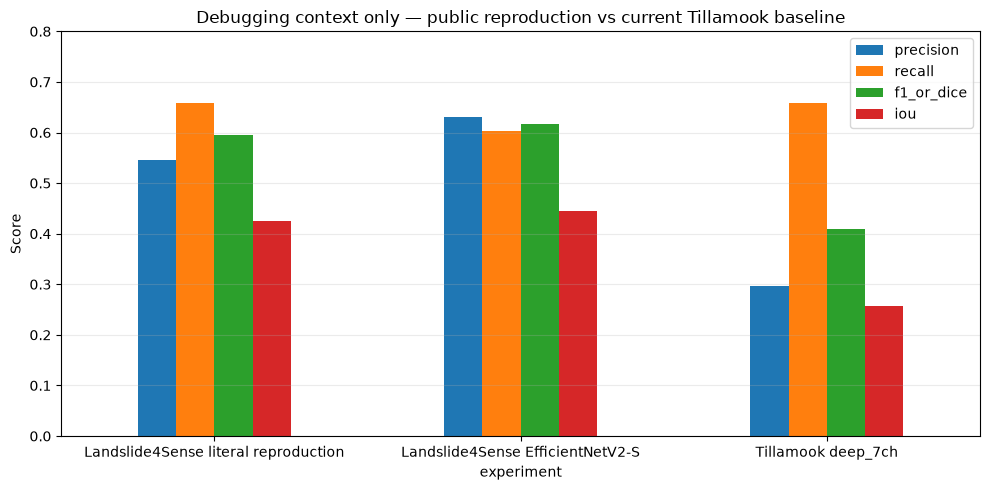

In [32]:

context_rows = []

if literal_obj is not None:
    m = literal_obj["validation"]
    context_rows.append({
        "experiment": "Landslide4Sense literal reproduction",
        "precision": m["precision"],
        "recall": m["recall"],
        "f1_or_dice": m["f1"],
        "iou": m["iou"],
    })

if efficientnet_obj is not None:
    m = efficientnet_obj["validation"]
    context_rows.append({
        "experiment": "Landslide4Sense EfficientNetV2-S",
        "precision": m["precision"],
        "recall": m["recall"],
        "f1_or_dice": m["f1"],
        "iou": m["iou"],
    })

if not till.empty:
    best = till.sort_values("dice", ascending=False).iloc[0]
    context_rows.append({
        "experiment": f"Tillamook {best['run']}",
        "precision": best["precision"],
        "recall": best["recall"],
        "f1_or_dice": best["dice"],
        "iou": best["iou"],
    })

context = pd.DataFrame(context_rows)
display(context.round(4))

if len(context):
    ax = context.set_index("experiment")[["precision","recall","f1_or_dice","iou"]].plot(
        kind="bar", figsize=(10,5), rot=0
    )
    ax.set_title("Debugging context only — public reproduction vs current Tillamook baseline")
    ax.set_ylabel("Score")
    ax.set_ylim(0,0.8)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGDIR / "context_public_vs_tillamook.png", dpi=180, bbox_inches="tight")
    plt.show()


## K. Automatic summary

In [33]:

summary_lines = []

if literal_obj is not None:
    m = literal_obj["validation"]
    summary_lines.append(
        f"Landslide4Sense literal-source reproduction: "
        f"P={m['precision']:.4f}, R={m['recall']:.4f}, F1={m['f1']:.4f}, IoU={m['iou']:.4f}."
    )
    summary_lines.append(
        f"Absolute difference from official reference: "
        f"ΔP={abs(m['precision']-OFFICIAL['precision']):.4f}, "
        f"ΔR={abs(m['recall']-OFFICIAL['recall']):.4f}, "
        f"ΔF1={abs(m['f1']-OFFICIAL['f1']):.4f}."
    )


if efficientnet_obj is not None and literal_obj is not None:
    e = efficientnet_obj["validation"]
    p = literal_obj["validation"]
    summary_lines.append(
        f"Landslide4Sense EfficientNetV2-S U-Net: "
        f"P={e['precision']:.4f}, R={e['recall']:.4f}, "
        f"F1={e['f1']:.4f}, IoU={e['iou']:.4f}."
    )
    summary_lines.append(
        f"EfficientNet change vs plain literal U-Net: "
        f"ΔP={e['precision']-p['precision']:+.4f}, "
        f"ΔR={e['recall']-p['recall']:+.4f}, "
        f"ΔF1={e['f1']-p['f1']:+.4f}, "
        f"ΔIoU={e['iou']-p['iou']:+.4f}, "
        f"FP reduction={100*(p['fp']-e['fp'])/p['fp']:.2f}%."
    )

if not till.empty:
    best = till.sort_values("dice", ascending=False).iloc[0]
    summary_lines.append(
        f"Tillamook current validation winner: {best['run']} "
        f"(Dice={best['dice']:.4f}, IoU={best['iou']:.4f}, "
        f"P={best['precision']:.4f}, R={best['recall']:.4f})."
    )
    if "predicted_positive_fraction" in best and "gt_positive_fraction" in best:
        summary_lines.append(
            f"Tillamook positive-area prevalence: "
            f"GT={100*best['gt_positive_fraction']:.2f}% vs "
            f"predicted={100*best['predicted_positive_fraction']:.2f}%."
        )

summary_lines.append("Tillamook internal test remains locked and is not loaded by this notebook.")

for line in summary_lines:
    print("•", line)

(ROOT / "analysis_figures_full" / "analysis_summary.txt").write_text(
    "\n".join(summary_lines),
    encoding="utf-8"
)


• Landslide4Sense literal-source reproduction: P=0.5449, R=0.6577, F1=0.5960, IoU=0.4245.
• Absolute difference from official reference: ΔP=0.0274, ΔR=0.0027, ΔF1=0.0178.
• Landslide4Sense EfficientNetV2-S U-Net: P=0.6301, R=0.6026, F1=0.6161, IoU=0.4452.
• EfficientNet change vs plain literal U-Net: ΔP=+0.0852, ΔR=-0.0551, ΔF1=+0.0200, ΔIoU=+0.0206, FP reduction=35.61%.
• Tillamook current validation winner: deep_7ch (Dice=0.4085, IoU=0.2567, P=0.2961, R=0.6584).
• Tillamook positive-area prevalence: GT=14.26% vs predicted=31.71%.
• Tillamook internal test remains locked and is not loaded by this notebook.


600


## Outputs

All generated PNG figures and CSV summaries are saved under:

```text
F:\LIDAR\oregon\analysis_figures_full\
```

Recommended figures to show the professor first:

1. `l4s_headline_metrics.png`
2. `l4s_plain_vs_efficientnet_metrics.png`
3. `l4s_plain_vs_efficientnet_fp_fn.png`
4. `l4s_plain_vs_efficientnet_positive_area.png`
5. `l4s_checkpoint_selection_f1_with_efficientnet.png`
6. `l4s_per_image_f1_change_efficientnet.png`
7. `sample4_mask_*.png` — four representative input/output sample panels
8. `montage14_mask_*.png` — optional 14-channel montages for those four samples
9. selected `qual_plain_vs_eff_mask_*.png`
10. `tillamook_2x2_metrics.png`
11. `tillamook_positive_area.png`
12. `tillamook_deep7_threshold_tradeoff.png`
13. `context_public_vs_tillamook.png` — debugging context only, not a formal benchmark comparison.

The notebook also writes:

```text
l4s_literal_per_image_metrics.csv
l4s_plain_vs_efficientnet_per_image_change.csv
analysis_summary.txt
```
